<a href="https://colab.research.google.com/github/Alien1001-r/An-AI-Driven-Approach-to-Unauthorized-Drone-Detection/blob/main/Another_copy_of_An_AI_Driven_Approach_to_Unauthorized_Drone_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**DUT Anti UAV**

####**Problem definition**

#### **The Context:**
With the rapid growth of drone technology drones are increasingly used in various fields such as delivery surveillance and entertainment. However unauthorized or malicious drone activities pose significant security threats to sensitive areas like airports.
The **DUT Anti-UAV** dataset was developed to support research in **visual drone detection**

####**The Objective:**

To explore and develop advanced computer vision models that can effectively detect drones using the DUT Anti-UAV dataset.


#### **The Key Questions:**
How can computer vision models be integrated by combining YOLO for detection and CNN for classification to accurately distinguish between authorized and unauthorized drones using the DUT Anti-UAV dataset?


##**Phase1 : Dataset Overview and Exploratory Data Analysis.**

####**1) Data Dictionary**
#####(Lujain)
---


* **folder:** the folder where the image is stored
* **filename:** the name of the image file
* **path:** the file path of the image
* **source, database:** the origin or dataset source of the image
* **size:** general information about the image size
* **width, height, depth:** the dimensions of the image (width, height, and color depth)
* **object:** the object present in the image ( drone )
* **name:** the label or name of the detected object
* **pose:** the pose or orientation of the object
* **truncated:** indicates whether the object is partially cut off
* **difficult:** shows if the object is difficult to detect
* **bndbox:** contains the bounding box coordinates
* **xmin, ymin, xmax, ymax:** the bounding box coordinates
* **segmented:** indicates whether the image includes segmentation or not


In [ ]:
# This code reads all XML annotation files from the DUT Anti-UAV training folder
# and lists all unique XML tag names to understand the dataset structure.

# Import necessary libraries
import os                              # Used to interact with files and folders
import xml.etree.ElementTree as ET     # Used to parse and read XML files
import pandas as pd                    # Used for data manipulation and creating DataFrames

# Display settings for pandas — show all columns and full width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ------------------------------
# Path to the training XML files
# ------------------------------
train_xml_path = "/content/drive/MyDrive/DUT_Anti_UAV/train/train/xml"

# ------------------------------
# Function to extract all unique XML tag names
# ------------------------------
def get_xml_columns(xml_folder):
    columns = set()  # Store unique tag names
    if os.path.exists(xml_folder):  # Check if path exists
        # Get all .xml files in the folder
        files = [f for f in os.listdir(xml_folder) if f.endswith('.xml')]
        for file in files:
            # Parse each XML file
            tree = ET.parse(os.path.join(xml_folder, file))
            root = tree.getroot()
            # Iterate through all XML elements and collect tag names
            for elem in root.iter():
                columns.add(elem.tag)
    return list(columns)

# ------------------------------
# Extract and display tag names for training data
# ------------------------------
train_columns = get_xml_columns(train_xml_path)
df_train_columns = pd.DataFrame([train_columns])

print(" Unique XML Tags in DUT Anti-UAV Training Dataset:")
display(df_train_columns)


 Unique XML Tags in DUT Anti-UAV Training Dataset:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,xmax,path,database,bndbox,pose,ymax,folder,truncated,ymin,xmin,width,height,difficult,filename,name,object,size,annotation,segmented,source,depth




#### **Observation:**

* This code scans all XML files in the training dataset and collects every unique tag name. This step helps identify the structure of the annotation files before converting them into a DataFrame, ensuring we know exactly which fields exist in the dataset.


####**2) Library Import & Path Setup**


---


This section initializes the environment for the DUT Anti-UAV project by importing essential libraries, defining dataset paths, and preparing settings for upcoming analysis.

In [ ]:
# =====================================================
# DUT Anti-UAV Dataset: Library Import & Path Setup
# =====================================================

#  Core Libraries (Used Now)
import os
import numpy as np
import pandas as pd

#  Visualization Libraries (Used Later for EDA)
import matplotlib.pyplot as plt
import seaborn as sns

#  Display all DataFrame columns
pd.set_option("display.max_columns", None)

# ==========================
#  Dataset Path Setup
# ==========================
base_path = "/content/drive/MyDrive/DUT_Anti_UAV"
train_path = os.path.join(base_path, "train")

print(" Dataset paths set successfully!")
print(f"Train folder: {train_path}")

# =====================================================
#  Optional: ML / DL Imports (Not Used Yet)
# =====================================================
# These libraries will be useful later during model training,
# but are not required for EDA / XML parsing steps.

from PIL import Image
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Disable warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# =====================================================
#  Observation
# =====================================================
# This code only sets up the environment, imports required libraries,
# and defines dataset paths. No data is loaded yet.


 Dataset paths set successfully!
Train folder: /content/drive/MyDrive/DUT_Anti_UAV/train


####**3) DUT Anti-UAV XML to DataFrame Pipeline**

---


Converts XML annotations from the DUT Anti-UAV dataset into a structured DataFrame, where each row represents a single object. The DataFrame is ready for analysis or machine learning tasks.


In [ ]:
# ============================================================
# Full DUT Anti-UAV XML -> DataFrame pipeline (Step A-C, E-F)
# - Extract unique XML tags (structure check)
# - Parse all annotations into a DataFrame (actual data columns)
# - Step D (numeric conversion) has been separated
# - Save final CSV for later use
# ============================================================

import os
import xml.etree.ElementTree as ET
import pandas as pd

# ------------------------------
# Configuration: path to XMLs
# ------------------------------
xml_folder = "/content/drive/MyDrive/DUT_Anti_UAV/train/train/xml"

# Safety check
if not os.path.exists(xml_folder):
    raise FileNotFoundError(f"XML folder not found: {xml_folder}")

# -------------------------------------------------
# Step A — Inspect unique XML tags
# -------------------------------------------------
def get_unique_tags(folder, sample_limit=None):
    tags = set()
    files = [f for f in os.listdir(folder) if f.endswith('.xml')]
    if sample_limit:
        files = files[:sample_limit]
    for fname in files:
        tree = ET.parse(os.path.join(folder, fname))
        root = tree.getroot()
        for elem in root.iter():
            tags.add(elem.tag)
    return sorted(tags)

unique_tags = get_unique_tags(xml_folder, sample_limit=20)
print(" Unique XML Tags (example sample):")
print(unique_tags)
print(f" Total unique tags (sample): {len(unique_tags)}\n")

# -------------------------------------------------
# Step B — Parse all XML files into a record list
# -------------------------------------------------
records = []
xml_files = [f for f in os.listdir(xml_folder) if f.endswith('.xml')]
print(f"Found {len(xml_files)} XML files. Parsing all...")

for xml_file in xml_files:
    tree = ET.parse(os.path.join(xml_folder, xml_file))
    root = tree.getroot()

    # Image-level fields
    filename = root.findtext('filename')
    folder   = root.findtext('folder')
    path     = root.findtext('path')
    source_db = root.findtext('source/database')
    segmented = root.findtext('segmented')
    width_text  = root.findtext('size/width')
    height_text = root.findtext('size/height')
    depth_text  = root.findtext('size/depth')

    # Object-level fields
    for obj in root.findall('object'):
        obj_name   = obj.findtext('name')
        pose       = obj.findtext('pose')
        truncated  = obj.findtext('truncated')
        difficult  = obj.findtext('difficult')
        xmin_text  = obj.findtext('bndbox/xmin')
        ymin_text  = obj.findtext('bndbox/ymin')
        xmax_text  = obj.findtext('bndbox/xmax')
        ymax_text  = obj.findtext('bndbox/ymax')

        records.append({
            'filename': filename,
            'folder': folder,
            'path': path,
            'source': source_db,
            'database': source_db,
            'segmented': segmented,
            'width': width_text,
            'height': height_text,
            'depth': depth_text,
            'object_name': obj_name,
            'pose': pose,
            'truncated': truncated,
            'difficult': difficult,
            'xmin': xmin_text,
            'ymin': ymin_text,
            'xmax': xmax_text,
            'ymax': ymax_text
        })

# -------------------------------------------------
# Step C — Convert to DataFrame
# -------------------------------------------------
df_train_full = pd.DataFrame(records)

print("\n Parsed DataFrame summary:")
print(f"Rows (object annotations): {len(df_train_full)}")
print(f"Columns: {len(df_train_full.columns)}")
print("Column names:", df_train_full.columns.tolist())

# -------------------------------------------------
# Step E — Basic sanity checks and info
# -------------------------------------------------
#print("\nℹ Example data (first 5 rows):")
#print(df_train_full.head())

# -------------------------------------------------
# Step F — Save DataFrame to CSV
# -------------------------------------------------
output_csv = "/content/drive/MyDrive/DUT_Anti_UAV/train_annotations_full.csv"
df_train_full.to_csv(output_csv, index=False)
print(f"\n💾 CSV saved at: {output_csv}")


 Unique XML Tags (example sample):
['annotation', 'bndbox', 'database', 'depth', 'difficult', 'filename', 'folder', 'height', 'name', 'object', 'path', 'pose', 'segmented', 'size', 'source', 'truncated', 'width', 'xmax', 'xmin', 'ymax', 'ymin']
 Total unique tags (sample): 21

Found 5200 XML files. Parsing all...

 Parsed DataFrame summary:
Rows (object annotations): 5243
Columns: 17
Column names: ['filename', 'folder', 'path', 'source', 'database', 'segmented', 'width', 'height', 'depth', 'object_name', 'pose', 'truncated', 'difficult', 'xmin', 'ymin', 'xmax', 'ymax']

💾 CSV saved at: /content/drive/MyDrive/DUT_Anti_UAV/train_annotations_full.csv



### **Observations**

1. **XML Structure:** 21 unique tags, including `annotation`, `object`, `bndbox`, `filename`, `size`, `xmin/ymin/xmax/ymax`. Standard PASCAL VOC style.

2. **Dataset Size:** 5200 XML files, 5243 object annotations. Most images have 1 object.

3. **DataFrame:** 17 columns combining image-level and object-level info. Numeric fields ready for bbox computation.

4. **Bounding Boxes:**

   * Width: 8–3570 px (mean ~80)
   * Height: 4–2144 px (mean ~43)
   * Area: 40–7.2M px² (mean ~13k)
   * Most boxes small; some very large (likely full-frame or errors).

5. **CSV Output:** Saved as `train_annotations_full.csv` for faster access.


#**Data Overview**



*   Observations
*   Sanity checks





**(6/1) Mount the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###**Observation :**
* Google Drive has been successfully mounted and is accessible at the path /content/drive.

**(6/2) Convert the data**

In [ ]:
# ==================================================
# Step D — Convert numeric-like columns to numbers
# ==================================================

numeric_cols = ['width', 'height', 'depth', 'xmin', 'ymin', 'xmax', 'ymax']

for col in numeric_cols:
    df_train_full[col] = pd.to_numeric(df_train_full[col], errors='coerce')

df_train_full['bbox_width'] = df_train_full['xmax'] - df_train_full['xmin']
df_train_full['bbox_height'] = df_train_full['ymax'] - df_train_full['ymin']
df_train_full['bbox_area'] = df_train_full['bbox_width'] * df_train_full['bbox_height']

print(" Bounding Box Columns Added Successfully!")
print(df_train_full[['filename','xmin','ymin','xmax','ymax','bbox_width','bbox_height','bbox_area']].head())


 Bounding Box Columns Added Successfully!
    filename  xmin  ymin  xmax  ymax  bbox_width  bbox_height  bbox_area
0  04201.jpg   741   349   771   362          30           13        390
1  04202.jpg  1442   466  1498   493          56           27       1512
2  04203.jpg  1283   371  1333   401          50           30       1500
3  04204.jpg  1036   483  1065   496          29           13        377
4  04205.jpg   457   437   486   455          29           18        522


###**Observation :**
* Bounding box calculations and feature extraction were successful. The output displays the calculated coordinates (xmin, ymin, xmax, ymax) and derived metrics (bbox_width, bbox_height, bbox_area) for the annotated objects.

**(6/3) Show The First 5 row**

In [ ]:
# -----------------------------
#  Display the first 5 rows
# -----------------------------
# .head() shows the top n rows of a DataFrame (default n=5)
print(" First 5 rows of the dataset:")
print(df_train_full.head())  # You can add a number inside head(), e.g., head(10), to show more rows

 First 5 rows of the dataset:
    filename folder               path                  source  \
0  04201.jpg  train  ./train/04201.jpg  DUT Anti-UAV Detection   
1  04202.jpg  train  ./train/04202.jpg  DUT Anti-UAV Detection   
2  04203.jpg  train  ./train/04203.jpg  DUT Anti-UAV Detection   
3  04204.jpg  train  ./train/04204.jpg  DUT Anti-UAV Detection   
4  04205.jpg  train  ./train/04205.jpg  DUT Anti-UAV Detection   

                 database segmented  width  height  depth object_name  \
0  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
1  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
2  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
3  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
4  DUT Anti-UAV Detection         0   1920    1080      3         UAV   

          pose truncated difficult  xmin  ymin  xmax  ymax  bbox_width  \
0  Unspecified         0         0   741   349   771   362  

### **Observation:**

* This code displays the first 5 rows of the dataset using `head()`, which helps verify that the data was loaded correctly and that all columns exist as expected.
* It is mainly used for a **quick visual inspection** before deeper analysis.



**(6/4) Show Info (rows and Columns )**

In [ ]:
# ==========================
# Start Exploring the Data
# ==========================

# Check how many rows and columns are present in the dataset
print("---------------------------------------------------------------------")
print("The dataset has the following shape (rows, columns):", df_train_full.shape)
print("---------------------------------------------------------------------\n")

# Use info() to print a concise summary of the dataset
# This helps to check data types, non-null counts, and total number of rows per column
df_train_full.info()


---------------------------------------------------------------------
The dataset has the following shape (rows, columns): (5243, 20)
---------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5243 entries, 0 to 5242
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   filename     5243 non-null   object
 1   folder       5243 non-null   object
 2   path         5243 non-null   object
 3   source       5243 non-null   object
 4   database     5243 non-null   object
 5   segmented    5243 non-null   object
 6   width        5243 non-null   int64 
 7   height       5243 non-null   int64 
 8   depth        5243 non-null   int64 
 9   object_name  5243 non-null   object
 10  pose         5243 non-null   object
 11  truncated    5243 non-null   object
 12  difficult    5243 non-null   object
 13  xmin         5243 non-null   int64 
 14  ymin         5243 non-null 


* The `.shape` function confirms the total number of rows (annotations) and columns (features) in the dataset, allowing us to verify dataset size.
* The `.info()` output provides a quick summary of each column, including data types and missing values, helping us understand data completeness and whether any columns need cleaning or conversion before analysis.



---


**Observation:**

* The DataFrame `df_train_full` was successfully loaded and contains **5243 rows and 20 columns**.
* Each row corresponds to a single object annotation in the dataset, not individual images.
* The columns include both **numeric fields** (10 columns, e.g., `width`, `height`, `xmin`, `ymin`, `xmax`, `ymax`, `bbox_width`, `bbox_height`, `bbox_area`) and **object/text fields** (10 columns, e.g., `filename`, `folder`, `object_name`, `pose`, `truncated`, `difficult`).
* All columns are **non-null**, meaning there are no missing values in the dataset.


**(6/5) Show Data Types**

In [ ]:
# ==========================
# Create Data Types Table for df_train_full
# ==========================

# Create a DataFrame that will store metadata about each column in the dataset
data_types_table = pd.DataFrame({

    # Store column names
    'Column': df_train_full.columns,

    # Store the data type of each column (e.g., int64, object, float64)
    'Data Type': df_train_full.dtypes.astype(str),

    # Categorize each column based on its type (text, integer, float, etc.)
    'Category': [
        'Categorical/Text' if dt=='object' else        # If dtype = object → treat as text
        'Integer' if dt=='int64' else                 # If dtype = int64 → integer column
        'Float' if dt=='float64' else                 # If dtype = float64 → float column
        'Other'                                        # Anything else gets labeled as "Other"
        for dt in df_train_full.dtypes.astype(str)
    ],

    # Display the first value from each column as an example
    'Example Value': [
        df_train_full[col].iloc[0] for col in df_train_full.columns
    ]
})

# Display the final table
data_types_table


,Column,Data Type,Category,Example Value
filename,filename,object,Categorical/Text,04201.jpg
folder,folder,object,Categorical/Text,train
path,path,object,Categorical/Text,./train/04201.jpg
source,source,object,Categorical/Text,DUT Anti-UAV Detection
database,database,object,Categorical/Text,DUT Anti-UAV Detection
segmented,segmented,object,Categorical/Text,0
width,width,int64,Integer,1920
height,height,int64,Integer,1080
depth,depth,int64,Integer,3
object_name,object_name,object,Categorical/Text,UAV



**Observation**

* Columns / Features: Each row represents a column in the dataset showing its name under Column and its data type under Data Type.

* Category: Columns are classified as either Categorical/Text (for string or label data) or Integer (for numeric data) helping to quickly understand the type of information each feature holds.

* Example Value: For each column the table shows a sample value from the first row (Example Value) to illustrate the kind of data it contains.


**(6/6) Show Statistical**

In [ ]:
# Include all columns in statistical summary
df_train_full.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
filename,5243,5197,00065.jpg,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
folder,5243,1,train,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
path,5243,5197,./train/00065.jpg,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,5243,1,DUT Anti-UAV Detection,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
database,5243,1,DUT Anti-UAV Detection,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segmented,5243,1,0,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
width,5243.0,NaN,NaN,NaN,1803.578867,297.576048,240.0,1920.0,1920.0,1920.0,5616.0
height,5243.0,NaN,NaN,NaN,1016.778371,167.657523,160.0,1080.0,1080.0,1080.0,3744.0
depth,5243.0,NaN,NaN,NaN,3.0,0.0,3.0,3.0,3.0,3.0,3.0
object_name,5243,1,UAV,5243,NaN,NaN,NaN,NaN,NaN,NaN,NaN



* This code builds a **data type summary table** that shows the column name, its data type, category (numeric/text), and an example value.
* It helps verify whether columns were correctly interpreted as `int`, `float`, or `object`, and makes it easier to detect wrong types (e.g., numbers stored as text).
* This table is useful for **quick dataset validation** before preprocessing or model training.

---


#### **Observation:**

* The DUT Anti-UAV training dataset contains **5243 object annotations** extracted from **5200 images**.
* The dataset includes **20 columns** covering image information, object details, and bounding box coordinates. All entries are complete .
* Images vary in resolution (width × height) and each contains at least one UAV, providing reliable data for object detection tasks.
* Bounding box dimensions (`bbox_width`, `bbox_height`, `bbox_area`) have a wide range, reflecting diverse object sizes within the dataset.

---

#### The dataset has **20 variables**:

* **Numerical (10):** `width`, `height`, `depth`, `xmin`, `ymin`, `xmax`, `ymax`, `bbox_width`, `bbox_height`, `bbox_area`
* **Categorical/Text (10):** `filename`, `folder`, `path`, `source`, `database`, `segmented`, `object_name`, `pose`, `truncated`, `difficult`


#**Exploratory Data Analysis (EDA)**

* Exploratory Data Analysis (EDA) helps us understand the dataset before using YOLO models.
* We check the number of images, their sizes and the main fields such as filename and width, height also bounding box coordinates.
* We also make sure there are no missing, corrupted, or duplicate files.
This helps us prepare clean and clear data for training YOLOv5 or YOLOv8 models.

**(3/1) Check for duplicate rows in the dataset**

---
(Reiam)

In [ ]:
# Check for duplicate rows in the dataset
duplicate_rows = df_train_full[df_train_full.duplicated()]

# Display number of duplicate rows
print("Number of duplicate rows:", duplicate_rows.shape[0])


Number of duplicate rows: 0


###**Observation :**
* the dataset contains 0 duplicate rows

**(3/2) Unique Values**

In [ ]:
# Example: Get unique values of a column
unique_values = df_train_full['object_name'].unique()
print("Unique object names:", unique_values)

# Optional: count how many unique values
print("Number of unique object classes:", len(unique_values))


Unique object names: ['UAV']
Number of unique object classes: 1


###**Observation :**
* The dataset contains annotations for only one unique object class, identified as 'UAV' (Unmanned Aerial Vehicle).

**(3/3) Check for Empty Values**

---






(Aljoharah)


In [ ]:
# ============================================
# Detect Empty String Values in 'source' Column
# ============================================

# Check first if the column exists (to avoid KeyError)
if 'source' in df_train_full.columns:
    # Count how many empty string values exist in the 'source' column
    empty_strings = (df_train_full['source'] == '').sum()  # True for empty cells, then sum counts them

    # Print the total number of empty string values
    print(f"Number of empty string values: {empty_strings}")  # Display count result

    # Show all rows where 'source' is an empty string
    if empty_strings > 0:
        print("\nRows with empty 'source' values:")  # Label for clarity
        display(df_train_full[df_train_full['source'] == ''])  # display() for nicer output
    else:
        print("\n No empty 'source' values found.")
else:
    print(" Column 'source' not found in DataFrame.")


Number of empty string values: 0

 No empty 'source' values found.


**Observation**

The dataset contains only one object class (UAV), has no Empty values in any column, and there are no duplicate rows.

**Sanity Checks**

All sanity checks show the dataset is clean and consistent. There are no Empty values or duplicate rows.

# **categorical :**

,filename,folder,path,source,database,segmented,object_name,pose,truncated,difficult
count,5243,5243,5243,5243,5243,5243,5243,5243,5243,5243
unique,5197,1,5197,1,1,1,1,1,1,1
top,00065.jpg,train,./train/00065.jpg,DUT Anti-UAV Detection,DUT Anti-UAV Detection,0,UAV,Unspecified,0,0
freq,6,5243,6,5243,5243,5243,5243,5243,5243,5243


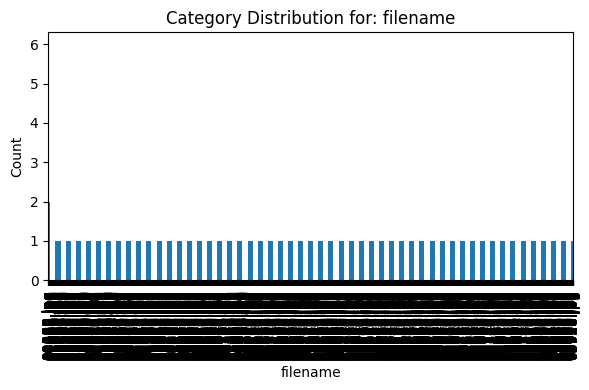

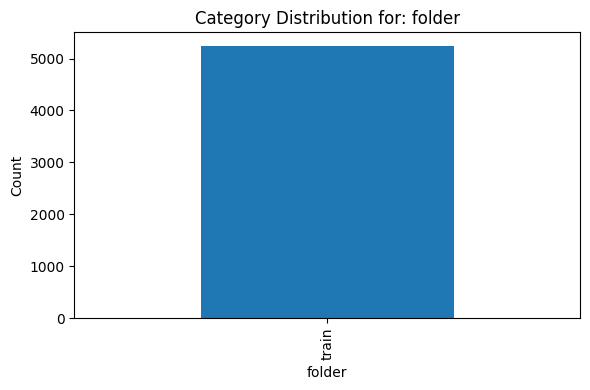

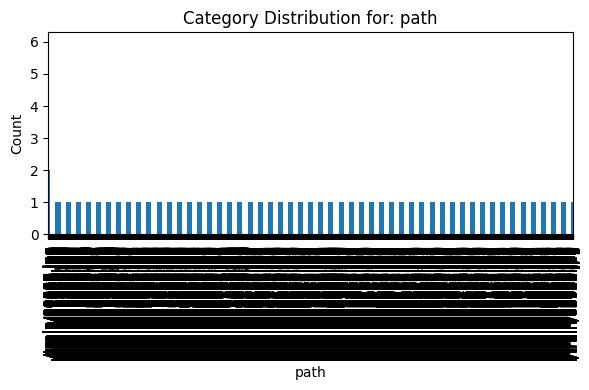

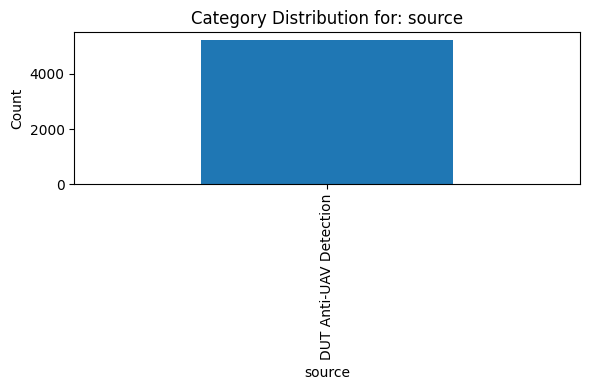

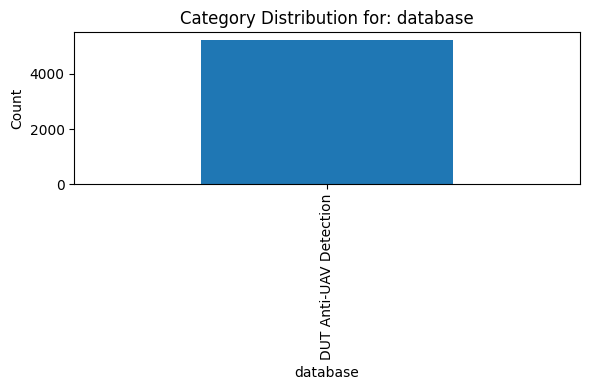

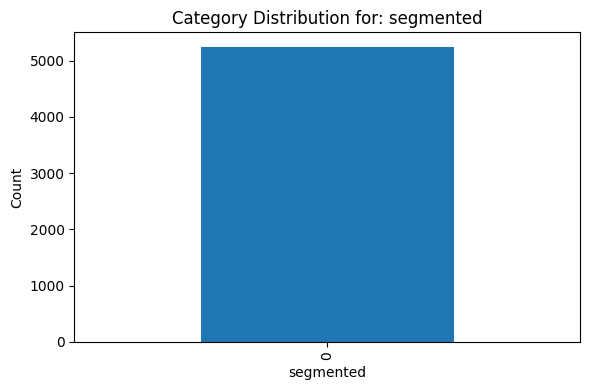

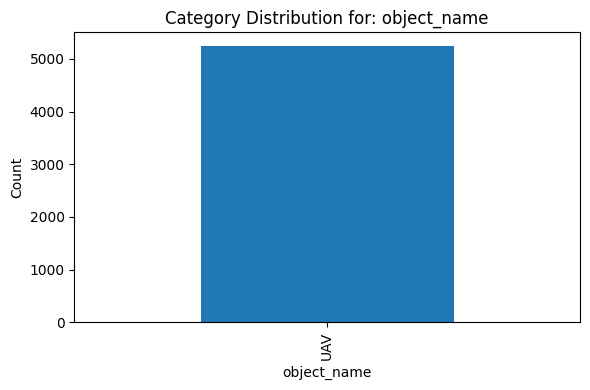

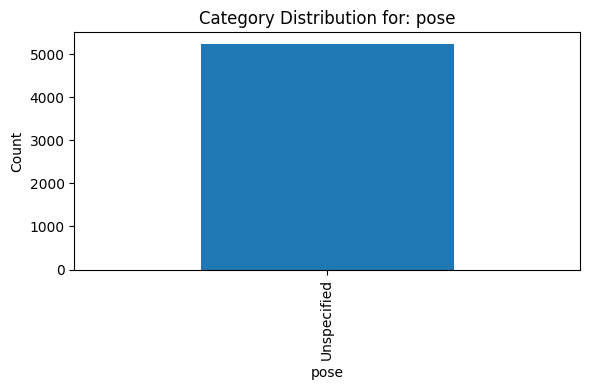

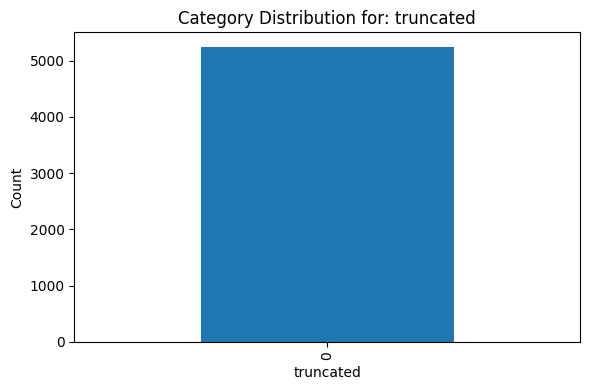

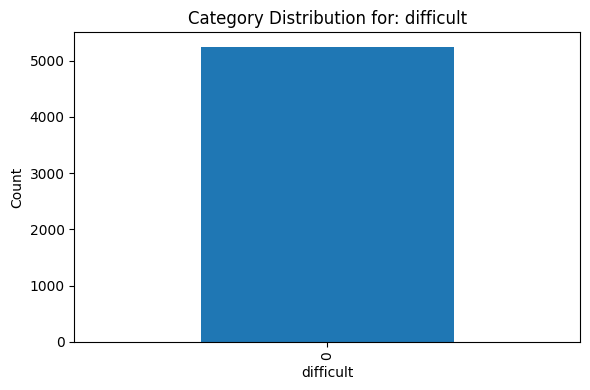

In [ ]:


# Select only categorical (object-type) columns from the DataFrame
categorical_cols = df_train_full.select_dtypes(include=['object']).columns

# Display full statistical summary for all categorical columns
#    This includes: count, unique values, top (most frequent) value, and its frequency
display(df_train_full[categorical_cols].describe(include='all'))

# Loop through each categorical column and plot its value distribution
for col in categorical_cols:
    plt.figure(figsize=(6,4))                     # Set figure size
    df_train_full[col].value_counts().plot(
        kind='bar'                                # Create bar chart
    )
    plt.title(f'Category Distribution for: {col}') # Title for the chart
    plt.xlabel(col)                               # X-axis label (column name)
    plt.ylabel('Count')                           # Y-axis label (frequency)
    plt.tight_layout()                            # Adjust layout to prevent text cut-off
    plt.show()                                    # Display the plot


**Observations :**
* Almost all images contain the same class: UAV.

* Distribution is not diverse : most values are identical.

# **Numerical :**

,width,height,depth,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area
count,5243.000000,5243.000000,5243.0,5243.000000,5243.000000,5243.00000,5243.000000,5243.000000,5243.000000,5.243000e+03
mean,1803.578867,1016.778371,3.0,875.141331,474.587831,954.84341,517.939920,79.702079,43.352088,1.296963e+04
std,297.576048,167.657523,0.0,393.275450,214.416565,374.67019,200.844732,130.880382,76.801945,1.490800e+05
min,240.000000,160.000000,3.0,1.000000,1.000000,17.00000,17.000000,8.000000,4.000000,4.000000e+01
25%,1920.000000,1080.000000,3.0,585.000000,312.000000,694.50000,373.000000,31.000000,17.000000,5.270000e+02
50%,1920.000000,1080.000000,3.0,881.000000,491.000000,950.00000,519.000000,43.000000,23.000000,9.690000e+02
75%,1920.000000,1080.000000,3.0,1158.500000,635.000000,1210.50000,657.000000,69.000000,36.000000,2.404000e+03
max,5616.000000,3744.000000,3.0,2054.000000,1056.000000,4556.00000,2891.000000,3570.000000,2144.000000,7.216704e+06


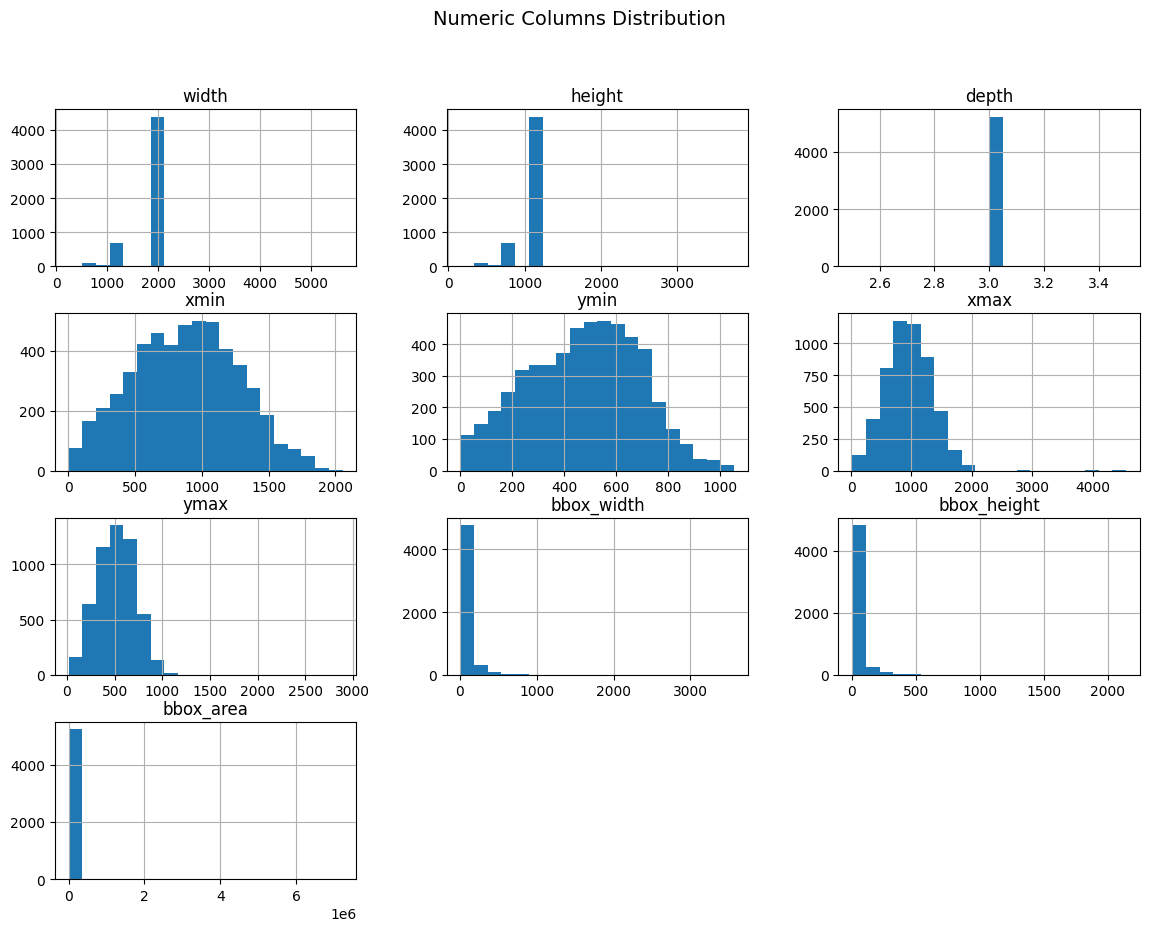

In [ ]:
# List of all numeric columns in the dataset
# These columns contain numerical values related to image size and bounding box details
num_cols = [
    'width', 'height', 'depth',          # Image-level metadata
    'xmin', 'ymin', 'xmax', 'ymax',      # Bounding box coordinates
    'bbox_width', 'bbox_height', 'bbox_area'  # Calculated bounding box info
]

# Convert the listed columns to numeric values (in case some were loaded as strings)
# errors='coerce' will turn invalid values into NaN instead of raising an error
df_train_full[num_cols] = df_train_full[num_cols].apply(pd.to_numeric, errors='coerce')

# Display descriptive statistics for the numeric columns
# Shows mean, median, std, min, max, etc.
display(df_train_full[num_cols].describe())

# Plot histograms for all numeric columns to visualize their distributions
df_train_full[num_cols].hist(bins=20, figsize=(14, 10))
plt.suptitle('Numeric Columns Distribution', fontsize=14)  # Main title for all subplots
plt.show()


###**Observation :**
#### **1. Image Dimensions (width, height)**

* The **average image resolution** in the dataset is approximately **1800 × 1000 pixels**.
* A large portion of the images share the same size:

  * **50% (median) of images are exactly 1920 × 1080 px**, which indicates a consistent video frame format (likely Full HD).
* There are a few **outliers with very large dimensions**, such as a width of **5616 px** and height of **3744 px**, suggesting some images come from higher-resolution cameras.

#### **2. Bounding Box Coordinates (xmin, ymin, xmax, ymax)**

* The **median object location** (bbox center) is roughly around coordinates:

  * **x ≈ 881 → 950 px**,
  * **y ≈ 491 → 519 px**,
    which means most UAVs are located near the center of the image.
* The **range shows outliers** — maximum values reach up to **(2054, 1056) for xmin/ymin** and **(4556, 2891) for xmax/ymax**, meaning some bounding boxes appear in very large images.

#### **3. Bounding Box Size (bbox_width, bbox_height, bbox_area)**

* The average bounding box size is small compared to image size:

  * Mean **width ≈ 80 px**,
  * Mean **height ≈ 43 px**,
    which confirms that UAVs appear **very small in the frame** (a common challenge in anti-UAV datasets).
* The **area ranges widely** — from **40 px²** to **7.2 million px²**, indicating presence of **huge outliers** (likely mislabeled or representing very close-up drone frames).

#### **4. Depth (channels)**

* The depth value is constant at **3 channels**, confirming that **all images are RGB** — no grayscale or multispectral data.

#### **5. General Distribution Notes**

* Most features have **centered distributions with long tails (right-skewed)**, especially `bbox_width`, `bbox_height`, and `bbox_area`.
* The dataset contains **significant scale variations** in both image size and object size .



###**Univariate analysis**








##**(20/0 ) width** :

---
Analyze the width column of the images in the dataset:

* Compute and display basic statistics: count, mean, standard deviation, minimum, maximum, quartiles, and number of unique widths.

* Understand the variation in image widths and detect possible anomalies or unusual sizes in the dataset.

(Lujain)


Width column statistics:

count    5243.000000
mean     1803.578867
std       297.576048
min       240.000000
25%      1920.000000
50%      1920.000000
75%      1920.000000
max      5616.000000
Name: width, dtype: float64

Number of unique widths: 83


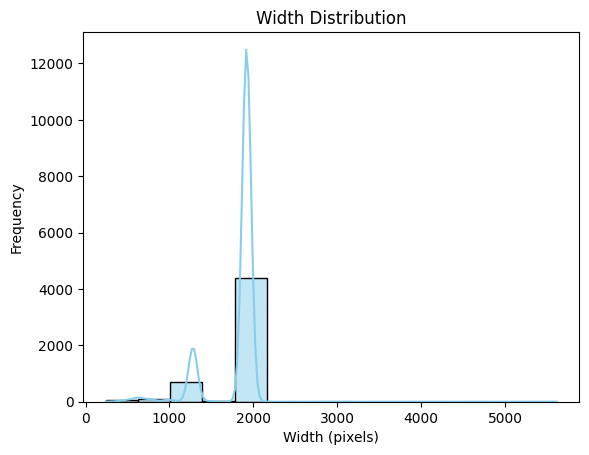

In [ ]:
# ---------------------------
# Display basic statistics for 'width'
# ---------------------------
width_series = df_train_full['width'].astype(int)  # Ensure numeric type
print("Width column statistics:\n")
print(width_series.describe())  # Count, mean, std, min, 25%, 50%, 75%, max

# Optional: print unique values or value counts
print("\nNumber of unique widths:", width_series.nunique())
#print("\nValue counts:\n", width_series.value_counts().sort_index())  # Uncomment to see counts of each width

# ---------------------------
# Plot histogram with KDE
# ---------------------------


sns.histplot(width_series, kde=True, color='skyblue')  # Histogram + KDE
plt.title('Width Distribution')       # Plot title
plt.xlabel('Width (pixels)')         # X-axis label
plt.ylabel('Frequency')               # Y-axis label
plt.show()                            # Display the plot


####**Observation** :

* Most images have a width of 1920 pixels (25th, 50th, 75th percentiles).

* Mean width ~1804, indicating some smaller and larger images shift the average.

* Std ~298, shows moderate variation around the main cluster.

* Min = 240, Max = 5616 → there are a few unusually small or very large images.

* 83 unique widths, but the majority are concentrated around 1920 pixels.



##**(20/1 ) height** :

---
Compute and analyze the height of bounding boxes in the dataset:

* Calculate bbox_height as the difference between ymax and ymin for each object.

* Generate basic statistics (count, mean, min, max, quartiles).

* Visualize the distribution of bounding box heights using a histogram.

(Aljoharah)

count    5243.000000
mean       43.352088
std        76.801945
min         4.000000
25%        17.000000
50%        23.000000
75%        36.000000
max      2144.000000
Name: bbox_height, dtype: float64


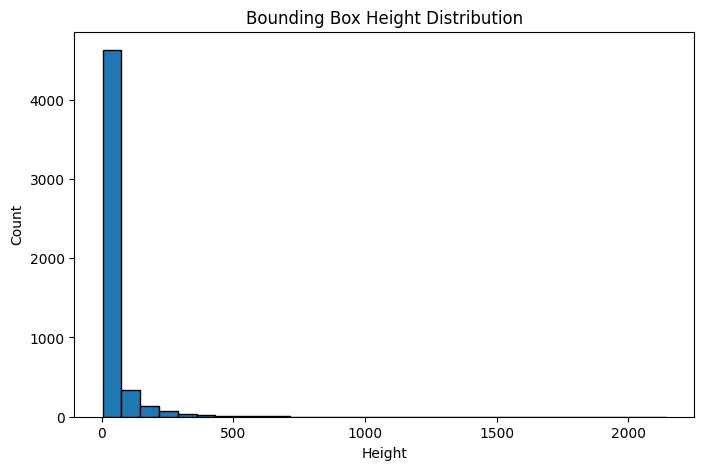

In [ ]:
# Calculate the height of the bounding box by subtracting the minimum y-coordinate (ymin) from the maximum y-coordinate (ymax).
# Ensure both coordinates are treated as integers before calculation.
df_train_full['bbox_height'] = df_train_full['ymax'].astype(int) - df_train_full['ymin'].astype(int)

# Print descriptive statistics (count, mean, standard deviation, min, max, quartiles) for the newly calculated 'bbox_height' column.
print(df_train_full['bbox_height'].describe())

# Visualize the distribution of the calculated bounding box heights using a histogram to identify the typical size,
# variability, and any outliers in the vertical dimension of the detected objects.
plt.figure(figsize=(8,5))
plt.hist(df_train_full['bbox_height'], bins=30, edgecolor='black')
plt.title("Bounding Box Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()


**Observation**

* Most bounding boxes are small in height, typically between 17 (25th percentile) and 36 pixels (75th percentile) indicating that UAVs occupy a relatively small vertical portion of the images.

* The maximum value of 2,144 is extremely high compared to the majority of data suggesting outlier cases or annotation errors where a bounding box might extend across almost the full image height.

##**(20/2 ) xmin :**

---
 Analyze the xmin column in the dataset to:

* Compute basic statistics such as count, mean, min, max, and quartiles.

* Visualize the distribution of xmin values using a histogram.

* Understand the horizontal positioning of objects in images and examine the range and spread of bounding box left coordinates.

(atheer)


count    5243.000000
mean      875.141331
std       393.275450
min         1.000000
25%       585.000000
50%       881.000000
75%      1158.500000
max      2054.000000
Name: xmin, dtype: float64


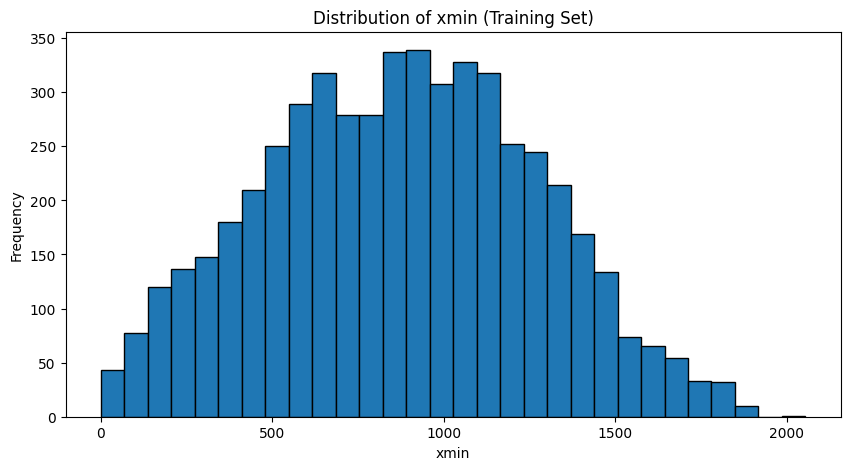

In [ ]:
# Extract the 'xmin' column from the existing DataFrame (df_train_full)
xmin_series = df_train_full['xmin'].astype(int)  # Ensure values are integers for numerical analysis

# Show basic statistics: count, mean, std, min, max, quartiles
print(xmin_series.describe())  # Summary statistics for xmin

# Plot histogram of xmin values
plt.figure(figsize=(10,5))  # Set figure size
plt.hist(xmin_series, bins=30, edgecolor="black")  # Draw histogram bars with black borders
plt.title("Distribution of xmin (Training Set)")  # Plot title
plt.xlabel("xmin")  # X-axis label
plt.ylabel("Frequency")  # Y-axis label
plt.show()  # Display the plot


**Observations**

* The xmin values range from 1 to 2054, with a mean of ~875 and a median of 881, indicating that most bounding boxes start roughly near the center-left region of the images.

* The data appears well-distributed horizontally with no extreme clustering on one side.

* However a minimum value of 1 suggests that some bounding boxes may begin at the very edge of the frame which could represent either true edge objects or annotation boundary cases.

##**(20/3 ) xmax :**

---
Analyze the xmax column in the dataset to:

* Compute basic statistics such as count, mean, min, max, and quartiles.

* Visualize the distribution of xmax values using a histogram.

* Understand the horizontal positioning of object boundaries (right edges) in the images.

(Atheer)


count    5243.00000
mean      954.84341
std       374.67019
min        17.00000
25%       694.50000
50%       950.00000
75%      1210.50000
max      4556.00000
Name: xmax, dtype: float64


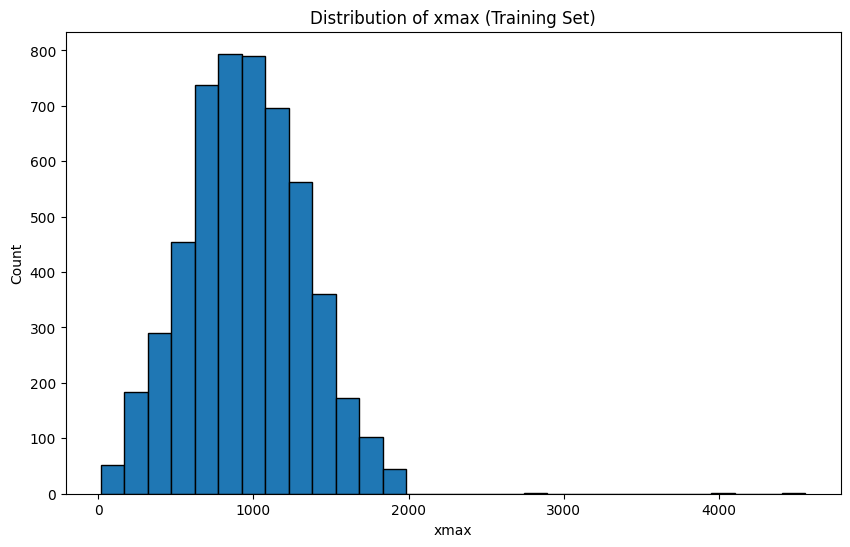

In [ ]:
# Extract the 'xmax' column from the existing DataFrame (df_train_full)
xmax_series = df_train_full['xmax'].astype(int)  # Ensure values are integers

# Display statistical summary (count, mean, std, min, max, quartiles)
print(xmax_series.describe())

# Plot the distribution of xmax values
plt.figure(figsize=(10,6))  # Set figure size
plt.hist(xmax_series, bins=30, edgecolor='black')  # Histogram bars
plt.title('Distribution of xmax (Training Set)')  # Plot title
plt.xlabel('xmax')  # X-axis label
plt.ylabel('Count')  # Y-axis label
plt.show()  # Display the plot


**Observations**
* The xmax values (representing the right boundary of bounding boxes) are mostly concentrated around the middle of the image with a mean of ~955 pixels and a median of 950 pixels indicating that most detected objects appear near the center horizontally.

* However a maximum value of 4556 exceeds the image width (1920 pixels) suggesting that some annotations contain outliers.




###**(20/4 ) ymin :**

---
Analyze the ymin column in the dataset:

* Display the top 10 most frequent ymin values.

* Compute basic statistics (count, mean, min, max, quartiles) and check for missing values.

* Understand the vertical positioning of the top boundary of objects in images.

(Atheer)


ymin
1      23
537    20
601    19
497    19
593    18
643    17
505    17
661    17
586    17
609    16
Name: count, dtype: int64
count    5243.000000
mean      474.587831
std       214.416565
min         1.000000
25%       312.000000
50%       491.000000
75%       635.000000
max      1056.000000
Name: ymin, dtype: float64
Missing values: 0


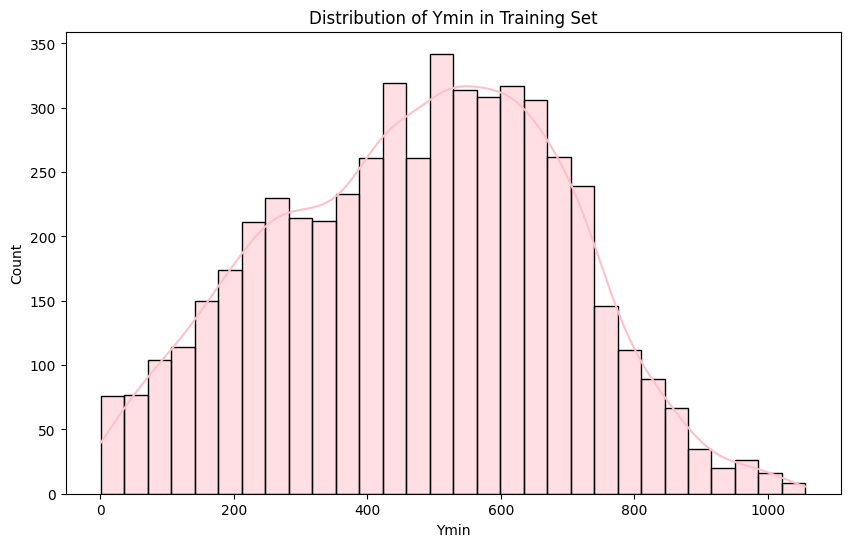

In [ ]:
ymin_series = df_train_full['ymin']  # Extract the 'ymin' column from the DataFrame

print(ymin_series.value_counts().head(10))  # Display the top 10 most frequent ymin values
print(ymin_series.describe())               # Show basic statistics: count, mean, std, min, max, quartiles
print(f"Missing values: {ymin_series.isnull().sum()}")  # Count missing values in 'ymin'

plt.figure(figsize=(10,6))  # Create a figure of size 10x6 inches
sns.histplot(ymin_series, bins=30, kde=True, color='pink')  # Plot a pink histogram with 30 bins and KDE
plt.title('Distribution of Ymin in Training Set')  # Set plot title
plt.xlabel('Ymin')  # Label x-axis
plt.ylabel('Count')  # Label y-axis
plt.show()  # Render the plot


**Observations**

* The ymin values range from 1 to 1056 pixels with a mean of approximately 475 and a standard deviation of 214, indicating a moderately wide spread.

* Most bounding boxes start between 300 and 650 pixels from the top of the image showing that UAVs are often located in the upper half of the frame.

* The histogram likely shows a peak around mid-to-low y values confirming that UAVs are typically captured in elevated regions of the image rather than near the bottom.

* No missing values were detected in this field confirming data completeness.



##**(20/5 ) ymax** :

---
Analyze the ymax column in the dataset to:

* Compute basic statistics such as count, mean, min, max, and quartiles.

* Visualize the distribution of ymax values using a histogram.

* Understand the vertical positioning of objects in images and assess the range and spread of bounding box bottom coordinates.

(Aljoharah)


count    5243.000000
mean      517.939920
std       200.844732
min        17.000000
25%       373.000000
50%       519.000000
75%       657.000000
max      2891.000000
Name: ymax, dtype: float64


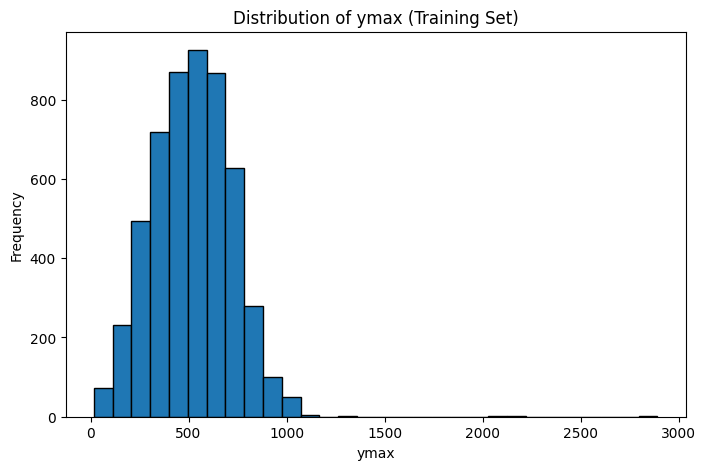

In [ ]:
# Extract the 'ymax' column from the existing DataFrame (df_train_full)
ymax_series = df_train_full['ymax'].astype(int)  # Convert values to integers to allow numeric analysis

# Display summary statistics for the 'ymax' values
print(ymax_series.describe())  # Shows count, mean, std, min, quartiles, and max

# Create a histogram to visualize the distribution of ymax values
plt.figure(figsize=(8,5))  # Set the figure size for the plot
plt.hist(ymax_series, bins=30, edgecolor="black")  # Draw histogram with 30 bins and black edges
plt.title("Distribution of ymax (Training Set)")  # Plot title
plt.xlabel("ymax")  # X-axis label
plt.ylabel("Frequency")  # Y-axis label
plt.show()  # Display the plot


**Observation**

* The ymax values range from 17 to 2891, with a mean of approximately 518 and a median of 519, showing that most bounding boxes extend to the middle or slightly lower part of the image.

* This suggests that UAVs are commonly detected around the center or lower vertical regions of the frame.

##**(20/6 ) bndbox** :

---
Analyze the xmin and ymin columns of bounding boxes in the dataset:

* Statistics: Compute and display basic statistics for each column, including count, mean, standard deviation, min, max, quartiles, and the number of unique values.

* Visualization: Plot histograms with Kernel Density Estimate (KDE) for both xmin and ymin to understand their distribution across the dataset.

* This helps identify the positioning of bounding boxes within images.

(Reiam)



Statistics for xmin:

count    5243.000000
mean      875.141331
std       393.275450
min         1.000000
25%       585.000000
50%       881.000000
75%      1158.500000
max      2054.000000
Name: xmin, dtype: float64
Number of unique values in xmin: 1554

Statistics for ymin:

count    5243.000000
mean      474.587831
std       214.416565
min         1.000000
25%       312.000000
50%       491.000000
75%       635.000000
max      1056.000000
Name: ymin, dtype: float64
Number of unique values in ymin: 929


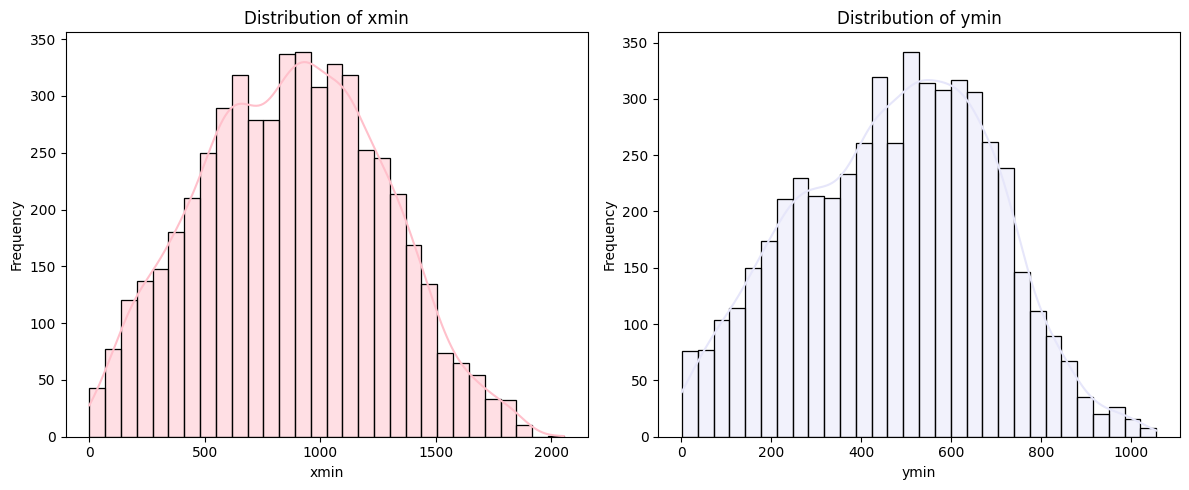

In [ ]:
# Print basic statistics for 'xmin' and 'ymin'
for col in ['xmin', 'ymin']:
    series = df_train_full[col].astype(int)  # Ensure numeric type
    print(f"\nStatistics for {col}:\n")
    print(series.describe())                 # Count, mean, std, min, 25%, 50%, 75%, max
    print(f"Number of unique values in {col}: {series.nunique()}")
    # Optional: print value counts
    # print(series.value_counts().sort_index())

# Plot histograms with KDE
fig, axes = plt.subplots(1, 2, figsize=(12,5))  # Create figure with 1 row, 2 columns
colors = {'xmin':'#FFC0CB','ymin':'#E6E6FA'}    # Define colors for each column
cols = ['xmin', 'ymin']                         # Columns to plot

for ax, col in zip(axes, cols):                # Loop through axes and columns
    sns.histplot(df_train_full[col].astype(int), kde=True, color=colors[col], bins=30, ax=ax)  # Histogram + KDE
    ax.set_title(f'Distribution of {col}')     # Set subplot title
    ax.set_xlabel(col)                          # Set x-axis label
    ax.set_ylabel('Frequency')                  # Set y-axis label

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()          # Display the plots


**Observations**

* xmin: Mean ≈ 875, range 1–2054, wide horizontal spread.


* ymin: Mean ≈ 475, range 1–1056, moderate vertical spread.


* Objects cover most of the image area, with some clustering near the center.

.


##**(20/7) size :**


---
Compute and analyze the image size in the dataset:

* Calculate img_size as the product of width and height for each image.

* Generate descriptive statistics (count, mean, min, max, quartiles).

* Visualize the distribution of image sizes using a histogram.

* Understand the range and variation of image resolutions.

(Lujain)


count    5.243000e+03
mean     1.883107e+06
std      5.892790e+05
min      3.840000e+04
25%      2.073600e+06
50%      2.073600e+06
75%      2.073600e+06
max      2.102630e+07
Name: img_size, dtype: float64


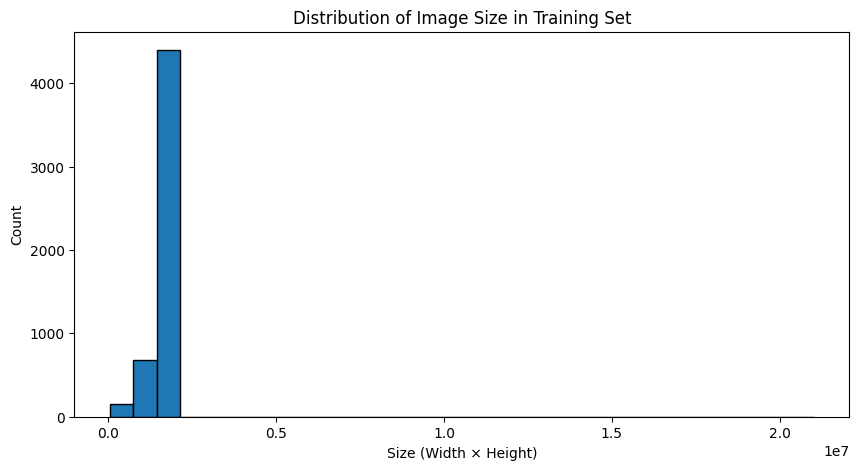

In [ ]:
# Compute image size (area) from DataFrame columns
df_train_full['img_size'] = df_train_full['width'].astype(int) * df_train_full['height'].astype(int)

# Show descriptive statistics
print(df_train_full['img_size'].describe())

# Plot histogram of image size
plt.figure(figsize=(10,5))
plt.hist(df_train_full['img_size'], bins=30, edgecolor='black')
plt.title("Distribution of Image Size in Training Set")
plt.xlabel("Size (Width × Height)")
plt.ylabel("Count")
plt.show()


**Observations**

* The img_size values show that most images have a consistent resolution of 2,073,600 pixels, corresponding to 1920×1080 (Full HD).

* However the presence of a minimum value of 38,400 and a maximum value of 21,026,300 indicates that a few images differ significantly in size.

* This suggests that while the majority of training images are uniform some outliers with unusual resolutions exist in the dataset.


###**(20/8 ) truncated :**

---
Analyze the truncated field in the training set to understand how objects are classified based on whether they are partially outside the image frame. The truncated column indicates:

* 0 = Not truncated: The object is fully visible within the image.

* 1 = Truncated: Part of the object lies outside the image boundaries.


(Aljoharah)


truncated
0    5243
Name: count, dtype: int64


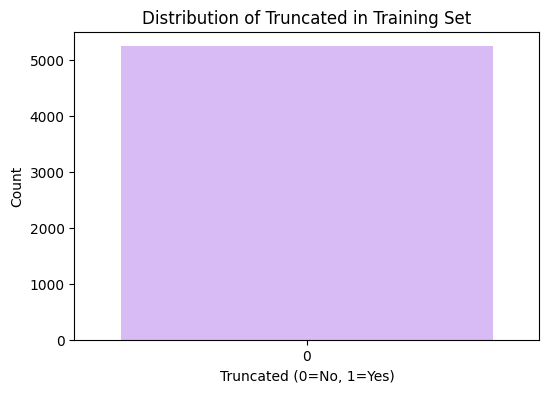

In [ ]:
truncated_counts = df_train_full['truncated'].astype(int).value_counts()  # Count the number of occurrences for each truncated value (0 or 1)
print(truncated_counts)  # Print the counts to the console

plt.figure(figsize=(6,4))  # Create a new figure for the plot with size 6x4 inches
sns.countplot(x=df_train_full['truncated'].astype(int), color='#D8B0FF')  # Plot distribution of truncated values as a bar chart with light purple color

plt.title('Distribution of Truncated in Training Set')  # Set the title of the plot
plt.xlabel('Truncated (0=No, 1=Yes)')  # Label the x-axis
plt.ylabel('Count')  # Label the y-axis

plt.show()  # Display the plot


**Observations:**

* All samples in the training dataset have a truncated value of 0, meaning none of the UAV objects are partially cut off at the image boundaries.

* This indicates that every UAV is fully visible within the frame. Such consistency ensures cleaner training data and reduces the complexity of object detection since the model doesn’t need to learn from incomplete objects.

##**(20/9 ) depth :**

---
Verify the image channel depth (e.g.,RGB channels) across the dataset and ensure consistency.

* Check for missing values and count unique depth values.

* Calculate the frequency and percentage of each depth value.

(Anood)



Missing values: 0
Unique values: 1

Value counts:
depth
3    5243
Name: count, dtype: int64

Percentage distribution:
depth
3    100.0
Name: proportion, dtype: float64


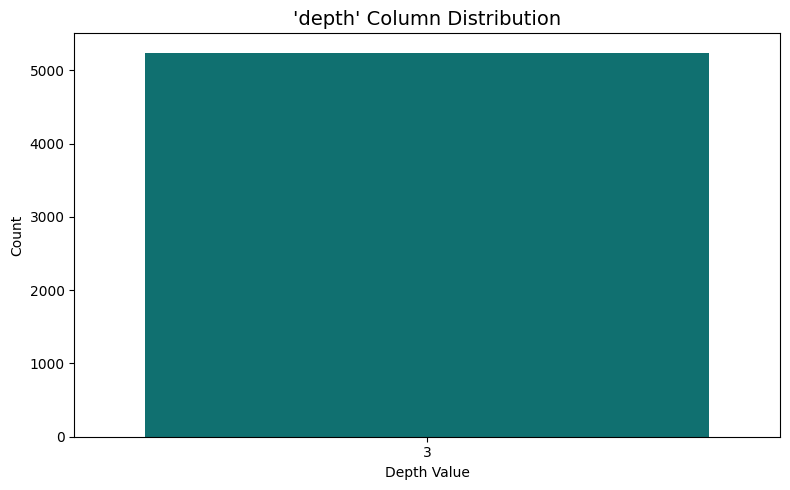

In [ ]:
# Analyze the 'depth' column directly from the existing dataframe

# Count missing values
missing = df_train_full['depth'].isnull().sum()

# Count unique values
unique = df_train_full['depth'].nunique()

# Value counts
counts = df_train_full['depth'].value_counts()

# Percentage distribution
percent = df_train_full['depth'].value_counts(normalize=True) * 100

# Print results
print(f"Missing values: {missing}")
print(f"Unique values: {unique}")
print("\nValue counts:")
print(counts)
print("\nPercentage distribution:")
print(percent.round(2))

# Plot
plt.figure(figsize=(8, 5))
sns.countplot(x='depth', data=df_train_full, order=counts.index, color='teal')
plt.title("'depth' Column Distribution", fontsize=14)
plt.xlabel('Depth Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation**

* The depth column has no missing values and only one unique value: 3.

* All 5,243 images are RGB images (3 channels).

* This confirms that the dataset is uniform in image channels.

##**(20/10 ) source :**

---
Understand the origin of images in the dataset and verify if all data comes from a single source or multiple sources.

* Obtain basic statistics and check the unique sources of images.

* Count how many images come from each source and calculate their percentage.

(Reiam)


count                       5243
unique                         1
top       DUT Anti-UAV Detection
freq                        5243
Name: source, dtype: object

Value Counts:
source
DUT Anti-UAV Detection    5243
Name: count, dtype: int64

Percentage distribution:
source
DUT Anti-UAV Detection    100.0
Name: proportion, dtype: float64


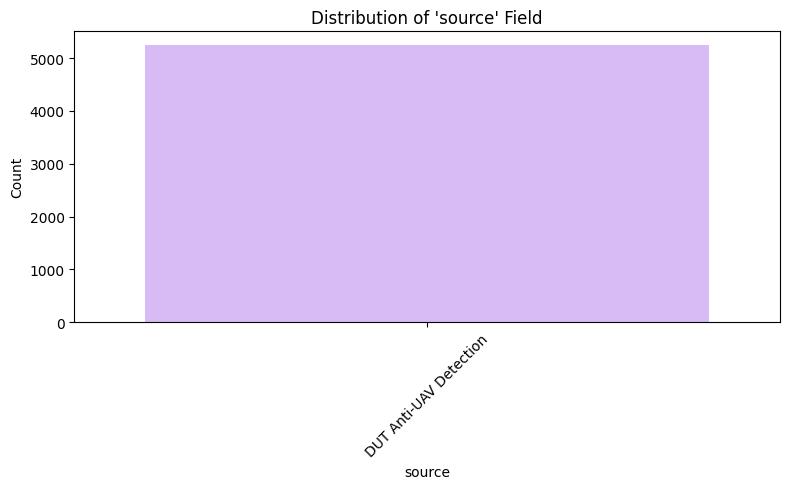

In [ ]:
# Analyze 'source' column from df_train_full

col = 'source'  # Column we want to analyze

# Basic stats
print(df_train_full[col].describe())

# Value counts
counts = df_train_full[col].value_counts()
percent = df_train_full[col].value_counts(normalize=True) * 100

print("\nValue Counts:")
print(counts)
print("\nPercentage distribution:")
print(percent.round(2))

# Plot distribution
plt.figure(figsize=(8,5))
sns.countplot(x=col, data=df_train_full, color='#D8B0FF')  # Light purple like your code
plt.title(f"Distribution of '{col}' Field")
plt.xlabel(col)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation**

* The source column contains only one unique value: "DUT Anti-UAV Detection".

* All 5,243 training images come from this single dataset representing 100% of the data.

##**(20/11 ) database :**


---
Analyze the database column in the dataset:


* Display summary statistics including total count, number of unique databases, the most frequent database, and its frequency.

* Verify the source of the dataset and ensure consistency or identify multiple sources of images.

(Muneera)

count                       5243
unique                         1
top       DUT Anti-UAV Detection
freq                        5243
Name: database, dtype: object


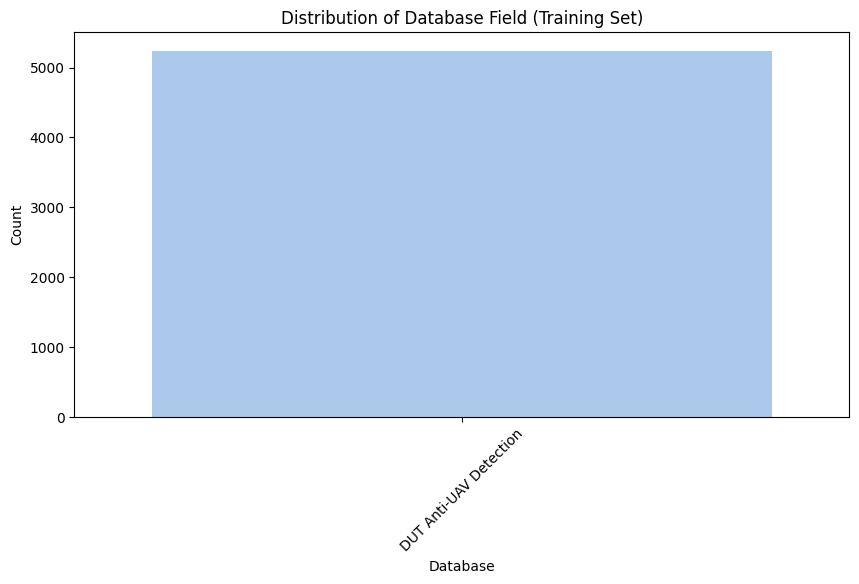

In [ ]:
# Extract the 'database' column from the main DataFrame (df_train_full)
database_series = df_train_full['database']  # Select the column

# Show basic statistics: count, unique, top, freq
print(database_series.describe())  # Summary statistics for database values

# Plot distribution of database values (if data exists)
if not database_series.empty:
    plt.figure(figsize=(10,5))  # Set figure size
    sns.countplot(x=database_series, palette='pastel')  # Bar chart with pastel colors
    plt.title('Distribution of Database Field (Training Set)')  # Plot title
    plt.xlabel('Database')  # X-axis label
    plt.ylabel('Count')  # Y-axis label
    plt.xticks(rotation=45)  # Rotate labels for readability
    plt.show()  # Display the plot
else:
    print("No <database> values found in the DataFrame.")


**Observation**
* The <database> field in the training dataset contains a single unique value: “DUT Anti-UAV Detection” appearing 5243 times.

* This indicates that all annotations originate from the same data source meaning the dataset is uniform and consistent in terms of origin.


##**(20/12) Folder :**

---
Verify the organization of images in the dataset and ensure consistency in folder structure.

* Check for missing values and count the number of unique folders.
* Determine how many images are in each folder and calculate their percentage.

* Visualize the distribution with a horizontal bar plot.

(Anood)



Missing values: 0
Unique values: 1

Value counts:
folder
train    5243
Name: count, dtype: int64

Percentage distribution:
folder
train    100.0
Name: proportion, dtype: float64


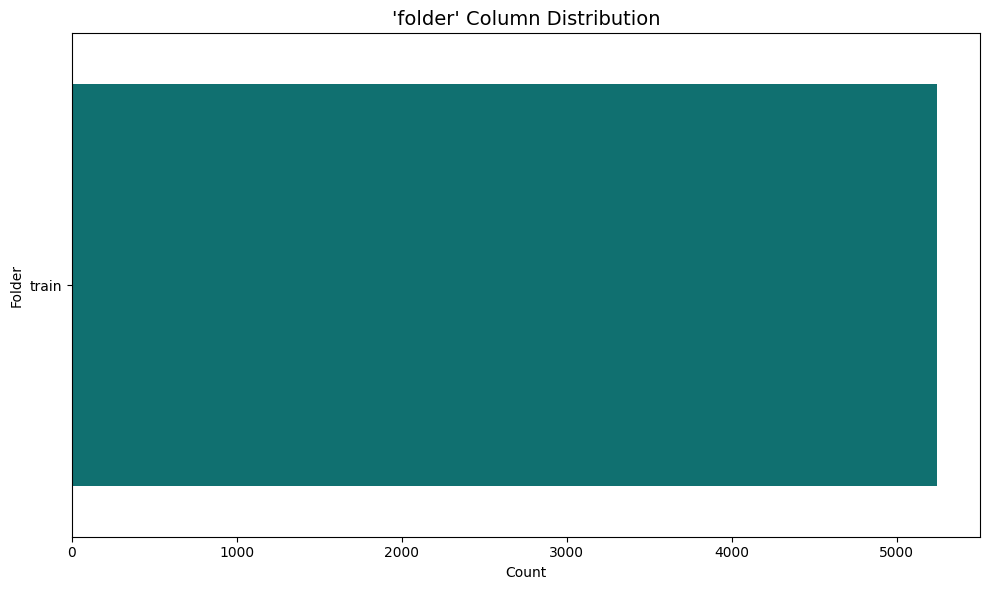

In [ ]:
# Analyze the 'folder' column directly from df_train_full


# Check if the 'folder' column exists in the DataFrame
if 'folder' in df_train_full.columns:
    # Extract the 'folder' column into a new DataFrame
    df_folder = df_train_full[['folder']].copy()


    # Basic Statistics

    # Count missing values (NaN)
    missing = df_folder['folder'].isnull().sum()

    # Count number of unique values
    unique = df_folder['folder'].nunique()

    # Count occurrence of each value
    counts = df_folder['folder'].value_counts()

    # Calculate percentage distribution of each value
    percent = df_folder['folder'].value_counts(normalize=True) * 100

    # Print results
    print(f"Missing values: {missing}")
    print(f"Unique values: {unique}")
    print("\nValue counts:")
    print(counts)
    print("\nPercentage distribution:")
    print(percent.round(2))

    # ----------------------------
    # Plotting the distribution
    # ----------------------------
    plt.figure(figsize=(10, 6))  # Set figure size

    # Horizontal bar chart using seaborn, ordered by count
    sns.countplot(y='folder', data=df_folder, order=counts.index, color='teal')

    # Add title and axis labels
    plt.title("'folder' Column Distribution", fontsize=14)
    plt.xlabel('Count')
    plt.ylabel('Folder')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

else:
    # If column does not exist, display a warning
    print("Column 'folder' does not exist in df_train_full.")


**Observation**

* The folder column has no missing values and only one unique value: "train".

* All 5,243 images are located in the train folder representing 100% of the dataset.

* This confirms that the dataset is entirely dedicated to training and is uniformly organized which simplifies data preprocessing and loading.

##**(20/13) Path :**

---
Ensure all image paths are valid, identify repeated images, and verify dataset integrity.

* Check for missing values and count the number of unique image paths.

* Determine how many times each image appears in the dataset and calculate its percentage.

(Anood)



Number of missing values: 0
Number of unique values: 5197

Value counts:
path
./train/00065.jpg    6
./train/00563.jpg    5
./train/00155.jpg    5
./train/00466.jpg    3
./train/00465.jpg    3
                    ..
./train/03929.jpg    1
./train/03928.jpg    1
./train/03927.jpg    1
./train/03926.jpg    1
./train/03936.jpg    1
Name: count, Length: 5197, dtype: int64

Percentage distribution:
path
./train/00065.jpg    0.11
./train/00563.jpg    0.10
./train/00155.jpg    0.10
./train/00466.jpg    0.06
./train/00465.jpg    0.06
                     ... 
./train/03929.jpg    0.02
./train/03928.jpg    0.02
./train/03927.jpg    0.02
./train/03926.jpg    0.02
./train/03936.jpg    0.02
Name: proportion, Length: 5197, dtype: float64


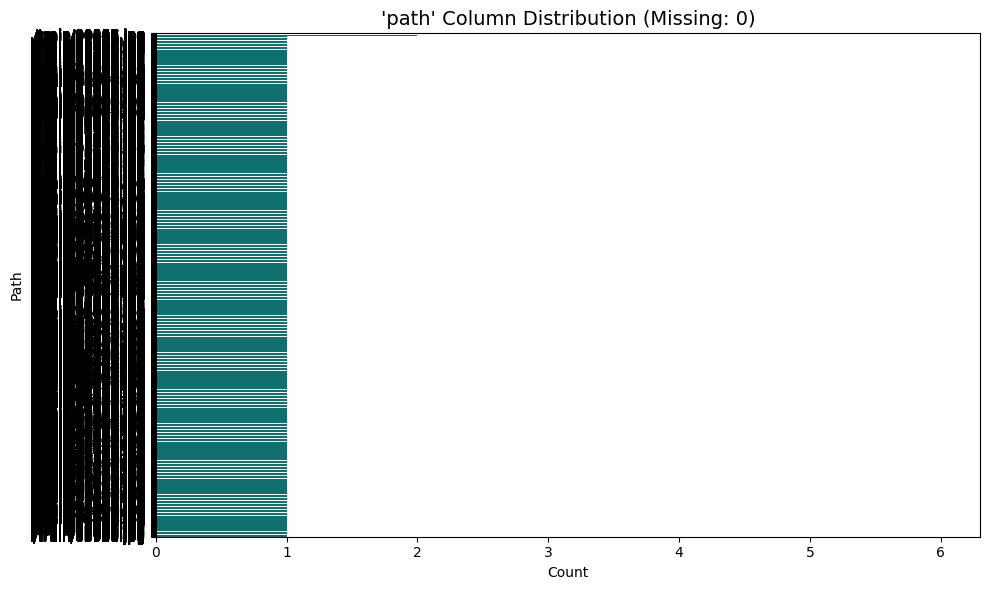

In [ ]:


# Use the 'path' column from df_train_full
df_path = df_train_full[['path']].copy()

# Basic analysis
num_missing = df_path['path'].isnull().sum()
unique_values = df_path['path'].nunique()
value_counts = df_path['path'].value_counts()
percent_dist = df_path['path'].value_counts(normalize=True) * 100

# Print results
print(f"Number of missing values: {num_missing}")
print(f"Number of unique values: {unique_values}")
print("\nValue counts:")
print(value_counts)
print("\nPercentage distribution:")
print(percent_dist.round(2))

# Plot distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='path', data=df_path, order=value_counts.index, color='teal')
plt.title(f"'path' Column Distribution (Missing: {num_missing})", fontsize=14)
plt.xlabel('Count')
plt.ylabel('Path')
plt.tight_layout()
plt.show()


**Observation**
* There are no missing values in the path column confirming all images are referenced.

* Out of 5,243 rows there are 5,197 unique paths meaning some images appear multiple times in the dataset.

* A few images such as 00065.jpg, appear 6 times while most images appear only once.

* This shows that some images have multiple annotations which is expected in object detection datasets where a single image may contain multiple UAVs.

##**(20/14 ) pose** :

---
Analyze the pose column in the dataset:

* Display the first few rows to verify the data.

* Plot the distribution of object poses using a count plot.

* Understand the orientation or pose categories of objects in the dataset, which is useful for detecting pose imbalance.

(Lujain)



    filename folder               path                  source  \
0  04201.jpg  train  ./train/04201.jpg  DUT Anti-UAV Detection   
1  04202.jpg  train  ./train/04202.jpg  DUT Anti-UAV Detection   
2  04203.jpg  train  ./train/04203.jpg  DUT Anti-UAV Detection   
3  04204.jpg  train  ./train/04204.jpg  DUT Anti-UAV Detection   
4  04205.jpg  train  ./train/04205.jpg  DUT Anti-UAV Detection   

                 database segmented  width  height  depth object_name  \
0  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
1  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
2  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
3  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
4  DUT Anti-UAV Detection         0   1920    1080      3         UAV   

          pose truncated difficult  xmin  ymin  xmax  ymax  bbox_width  \
0  Unspecified         0         0   741   349   771   362          30   
1  Unspecified  

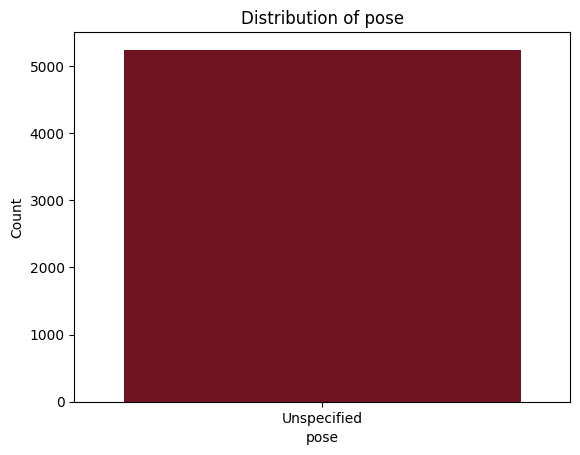

In [ ]:
# Display first 5 rows of df_train_full  # Verify data
print(df_train_full.head())

# Plot distribution of 'pose'  # Count of objects per pose category
sns.countplot(x='pose', data=df_train_full, color='#800517')

plt.title('Distribution of pose')  # Plot title
plt.xlabel('pose')                 # X-axis label
plt.ylabel('Count')                # Y-axis label
plt.show()                         # Show the plot


**Observations**

* The pose field in the training dataset contains only the value “Unspecified” for all entries.

* This indicates that no pose or orientation information is provided for the UAV objects.

* As a result the dataset focuses solely on object localization (bounding box coordinates) rather than capturing different viewpoints or orientations of the UAVs.


##**(20/15 ) segmented :**


---
Analyze the segmented column in the dataset:

* Display the first few rows to ensure the column exists.

* Plot the distribution of segmented values using a count plot.

* Check how many objects have segmentation annotations and understand the balance between segmented and non-segmented objects in the dataset.

(Muneera)

    filename folder               path                  source  \
0  04201.jpg  train  ./train/04201.jpg  DUT Anti-UAV Detection   
1  04202.jpg  train  ./train/04202.jpg  DUT Anti-UAV Detection   
2  04203.jpg  train  ./train/04203.jpg  DUT Anti-UAV Detection   
3  04204.jpg  train  ./train/04204.jpg  DUT Anti-UAV Detection   
4  04205.jpg  train  ./train/04205.jpg  DUT Anti-UAV Detection   

                 database segmented  width  height  depth object_name  \
0  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
1  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
2  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
3  DUT Anti-UAV Detection         0   1920    1080      3         UAV   
4  DUT Anti-UAV Detection         0   1920    1080      3         UAV   

          pose truncated difficult  xmin  ymin  xmax  ymax  bbox_width  \
0  Unspecified         0         0   741   349   771   362          30   
1  Unspecified  

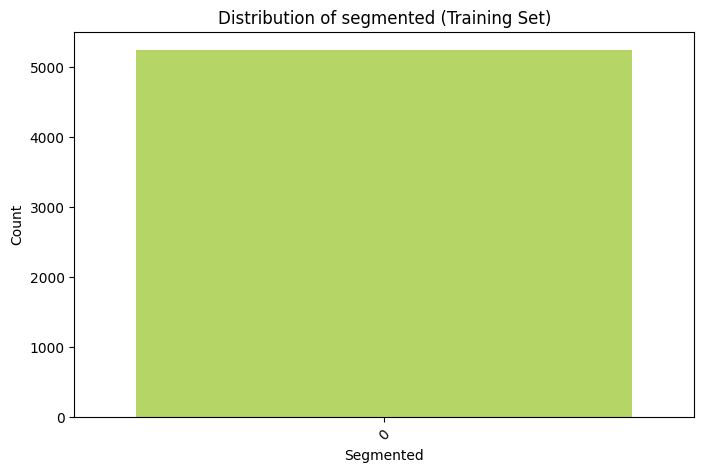

In [ ]:
# Display first 5 rows of df_train_full to verify the 'segmented' column exists
print(df_train_full.head())

# Plot distribution of 'segmented' column (counts of each category)
plt.figure(figsize=(8,5))  # Set figure size for better visibility
sns.countplot(x='segmented', data=df_train_full, color='#BCE954')  # Bar plot with custom color

plt.title('Distribution of segmented (Training Set)')  # Plot title
plt.xlabel('Segmented')                                # X-axis label
plt.ylabel('Count')                                    # Y-axis label
plt.xticks(rotation=45)                                # Rotate labels if needed
plt.show()                                             # Display the plot


**Observations**

* The <segmented> column in the training dataset contains only the value 0 across all samples indicating that no segmentation masks are provided for any of the images.

* This means the dataset is exclusively designed for object detection tasks using bounding boxes rather than instance or semantic segmentation.




##**(20/16 ) name :**

---
Get an overview of object classes in the dataset and check if the dataset is balanced or dominated by a single class.

* Obtain basic statistics about the object labels.

* Count the occurrences of each label and calculate their percentage.

(Anood)



count     5243
unique       1
top        UAV
freq      5243
Name: object_name, dtype: object

Value counts:
object_name
UAV    5243
Name: count, dtype: int64

Percentage distribution:
object_name
UAV    100.0
Name: proportion, dtype: float64


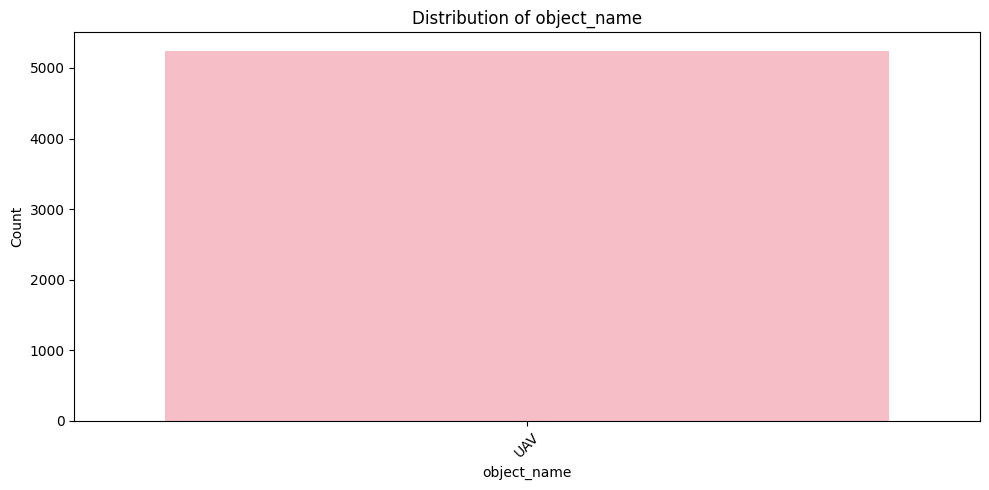

In [ ]:
# Extract and analyze 'object_name' values
# Using existing df_train_full


# Column to analyze
col = 'object_name'

# Basic stats
print(df_train_full[col].describe())

# Value counts
counts = df_train_full[col].value_counts()
percent = df_train_full[col].value_counts(normalize=True) * 100

print("\nValue counts:")
print(counts)
print("\nPercentage distribution:")
print(percent.round(2))

# Plot
plt.figure(figsize=(10,5))
sns.countplot(x=col, data=df_train_full, color='#FFB6C1')  # Same baby pink color
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation**
* The object_name column contains only one unique value: "UAV" covering 100% of the training dataset (5,243 samples).

* This indicates that the dataset is single-class focusing exclusively on UAV detection.

* While this provides a clear and focused dataset for training the model.

##**(20/17 ) filename :**

---
Check and analyze the file identifier column:


* Determine whether file or filename exists in the dataset.


* Display basic statistics (count, unique values, most frequent files).


* Identify how many unique images are present detect duplicates and understand the distribution of annotations across files.

(Atheer)



✅ Found column: 'filename'

Statistics for filename:
 count          5243
unique         5197
top       00065.jpg
freq              6
Name: filename, dtype: object


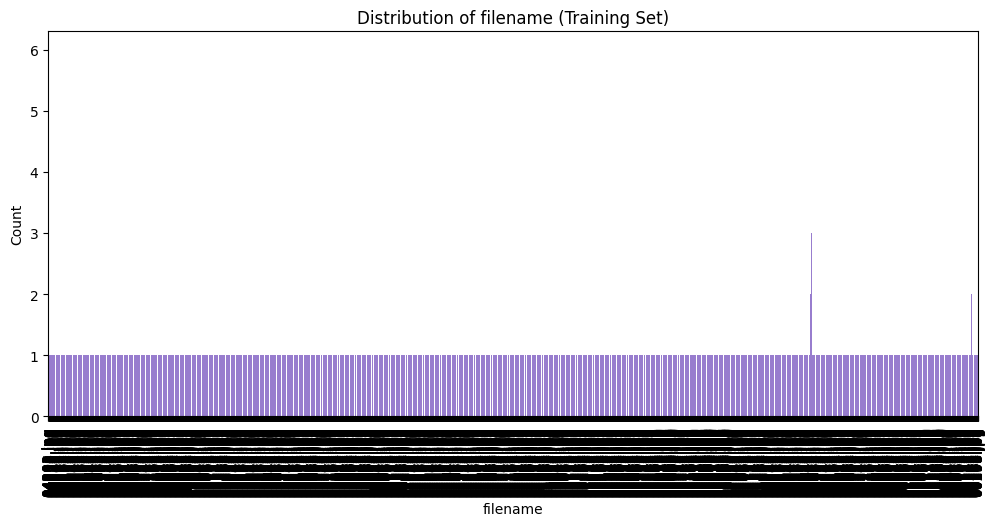

In [ ]:
# List of possible column names we want to test
possible_columns = ['file', 'filename']

# Check which one exists in the DataFrame
found_col = None
for col in possible_columns:
    if col in df_train_full.columns:
        found_col = col
        break

# If a valid column was found, run stats + plot
if found_col:
    print(f"\n Found column: '{found_col}'\n")

    # Show basic statistics
    print(f"Statistics for {found_col}:\n", df_train_full[found_col].describe())

    # Plot the distribution
    plt.figure(figsize=(12,5))
    sns.countplot(x=found_col, data=df_train_full, color='#9370DB')  # Light purple bars
    plt.title(f'Distribution of {found_col} (Training Set)')
    plt.xlabel(found_col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)  # Rotate labels if long
    plt.show()

else:
    print("⚠️ Neither 'file' nor 'filename' column exists in df_train_full")
    print(" Available columns are:\n", list(df_train_full.columns))


**Observations**

* There are 5243 objects across 5197 unique files so most files contain a single object with very few containing multiple objects.

* The most frequent file 00065.xml, has 6 objects.

##**(20/18 ) annotation :**

---
Understand which object classes are present in the dataset and their relative proportions, helping to assess class balance for training.

* Extract the object_name column to identify all object labels.

* Count the number of occurrences and calculate the percentage of each label.

(Anood)


📊 Annotation Label Counts:
  label  count  percentage
0   UAV   5243       100.0


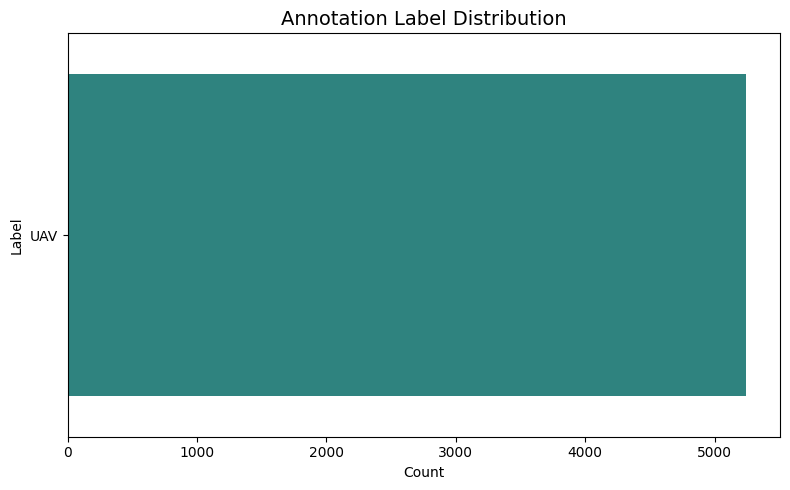

In [ ]:
# Annotation Label Distribution
# Using existing DataFrame df_train_full



# Extract the 'object_name' column
labels = df_train_full['object_name']

# Count and percentage
df_labels = labels.value_counts().reset_index()
df_labels.columns = ['label', 'count']
df_labels['percentage'] = (df_labels['count'] / df_labels['count'].sum()) * 100

# Print summary
print(" Annotation Label Counts:")
print(df_labels)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='count', y='label', data=df_labels, hue='label', dodge=False, palette='viridis', legend=False)
plt.title("Annotation Label Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Label")
plt.tight_layout()
plt.show()


**Observation**

* The annotation label distribution shows that all 5,243 samples (100%) are labeled as “UAV”.

* This confirms that the dataset is single-class focusing solely on UAV detection.

* While this provides a consistent and focused dataset for training.

##**(20/19 ) Difficult :**

---
Assess the difficulty level of annotated objects in the dataset which can guide training strategies.

* Check for missing values.

* Count the occurrence of each unique value (0 = easy, 1 = difficult).

(Anood)


Number of missing values: 0
Value distribution:
difficult
0    5243
Name: count, dtype: int64


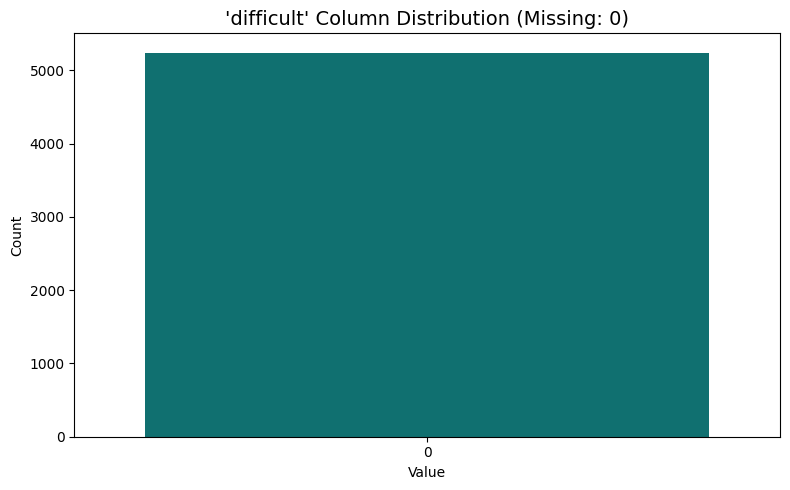

In [ ]:
# Analyze the 'difficult' column directly from df_train_full


# Check if the 'difficult' column exists in the DataFrame
if 'difficult' in df_train_full.columns:
    # Extract the 'difficult' column into a new DataFrame
    df_difficult = df_train_full[['difficult']].copy()


    # Basic Analysis

    # Count how many missing values (NaN) exist in the 'difficult' column
    num_missing = df_difficult['difficult'].isnull().sum()

    # Count the occurrence of each unique value in the 'difficult' column
    value_counts = df_difficult['difficult'].value_counts()

    # Print the results for quick inspection
    print(f"Number of missing values: {num_missing}")
    print(f"Value distribution:\n{value_counts}")

    # ----------------------------
    # Plotting the distribution
    # ----------------------------
    plt.figure(figsize=(8, 5))  # Set the figure size for clarity

    # Create a count plot of the 'difficult' values using seaborn
    sns.countplot(x='difficult', data=df_difficult, color='teal')

    # Add a title with the missing values info
    plt.title(f"'difficult' Column Distribution (Missing: {num_missing})", fontsize=14)

    # Label x-axis and y-axis
    plt.xlabel('Value')
    plt.ylabel('Count')

    # Adjust layout to prevent overlapping elements
    plt.tight_layout()

    # Show the plot
    plt.show()

else:
    # If the column does not exist, display a warning
    print("Column 'difficult' does not exist in df_train_full.")


**Observation**

* The difficult column has no missing values and all 5,243 entries are 0.

* This indicates that all objects in the dataset are considered easy to detect.


##**(20/20 ) object :**

---
Analyze the object_name column in the dataset:


* Display summary statistics such as total count, unique object types, most frequent label, and its frequency.

* Understand which object classes are present in the dataset and check for class imbalance.

(Reiam)


count     5243
unique       1
top        UAV
freq      5243
Name: object_name, dtype: object


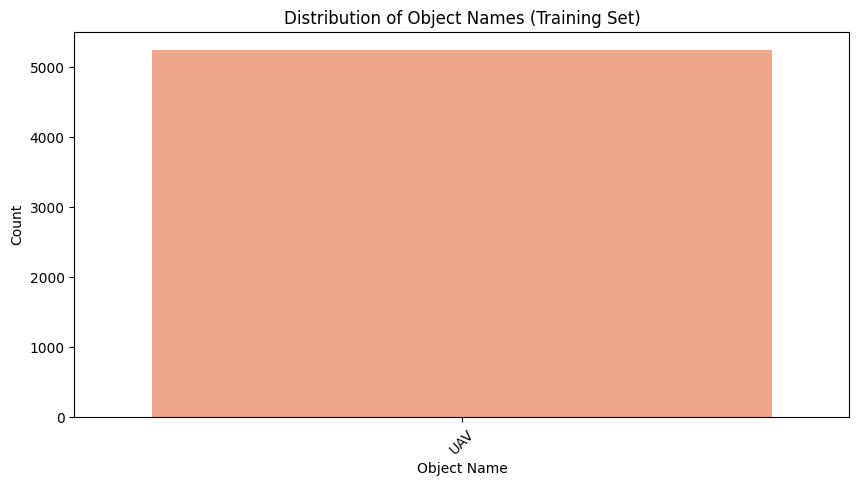

In [ ]:
# Extract the 'object_name' column (labels of detected objects)
object_series = df_train_full['object_name']  # Select the column from DataFrame

# Show basic statistics: count, unique, top, freq
print(object_series.describe())  # Summary statistics for object labels

# Plot distribution of object names
plt.figure(figsize=(10,5))  # Set figure size
sns.countplot(x=object_series, color='#FFA07A')  # Light salmon color for bars
plt.title('Distribution of Object Names (Training Set)')  # Plot title
plt.xlabel('Object Name')  # X-axis label
plt.ylabel('Count')  # Y-axis label
plt.xticks(rotation=45)  # Rotate labels for readability
plt.show()  # Display the plot


**Observation**
* The <object_name> field shows that all 5,243 entries are labeled as “UAV.”

* This indicates that the training dataset contains only one object class meaning it is single-class rather than multi-class.

###**bivariate analysis**


### **(5/1) Width vs Height (numeric vs numeric)**

(Relationship between bounding box width and height for each object class)

---
(Aljoharah)


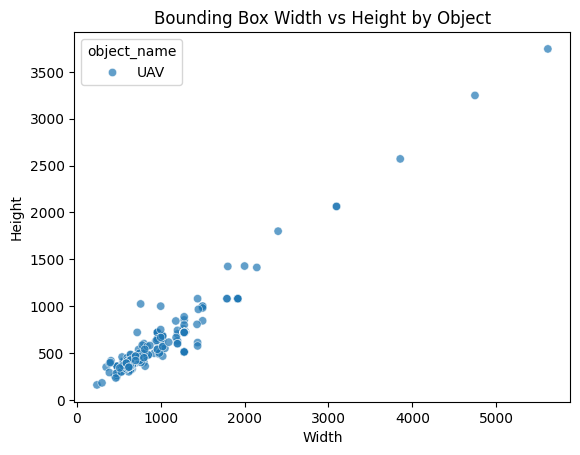

In [ ]:
# Scatter plot: width vs height, colored by object class
sns.scatterplot(
    data=df_train_full,       # Use the main DataFrame
    x='width',                # Width of bounding box
    y='height',               # Height of bounding box
    hue='object_name',        # Correct column name for object labels
    alpha=0.7                 # Transparency for overlapping points
)

# Add descriptive title
plt.title('Bounding Box Width vs Height by Object')

# Label axes
plt.xlabel('Width')
plt.ylabel('Height')

# Display the plot
plt.show()


### **Observation:**
 This plot shows the relationship between width and height of bounding boxes.

Most UAV bounding boxes are small, indicating drones occupy a small portion of images.

The width and height are roughly proportional for most objects, suggesting consistent aspect ratios.

Few outliers exist with unusually large width or height.

### **(5/2) Size (area) vs Width (numeric vs numeric)**


(Relationship between bounding box width and size(area) for each object class)


---


(Lujain)


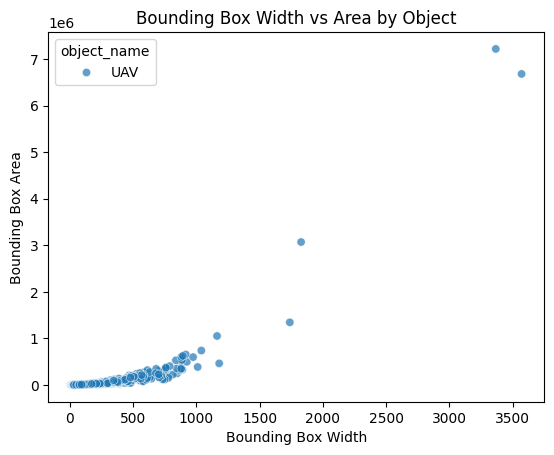

In [ ]:
# Scatter plot: width vs area
sns.scatterplot(
    data=df_train_full,       # Main DataFrame
    x='bbox_width',           # Bounding box width
    y='bbox_area',            # Bounding box area
    hue='object_name',        # Object classes
    alpha=0.7                 # Transparency
)

# Add title and labels
plt.title('Bounding Box Width vs Area by Object')
plt.xlabel('Bounding Box Width')
plt.ylabel('Bounding Box Area')

# Show plot
plt.show()


### **Observation:**
 This shows if larger width corresponds to larger area.
Width vs Area

Larger width generally leads to larger area, as expected (area = width × height).

Extreme points (very large areas) indicate rare large objects.

Distribution is heavily right-skewed, consistent with skewness calculation.

 ### **(5/3) Height by Object (numeric vs categorical)**

(how numeric values vary by category)

(Distribution of bounding box height for each object class)

---
(Reiam)


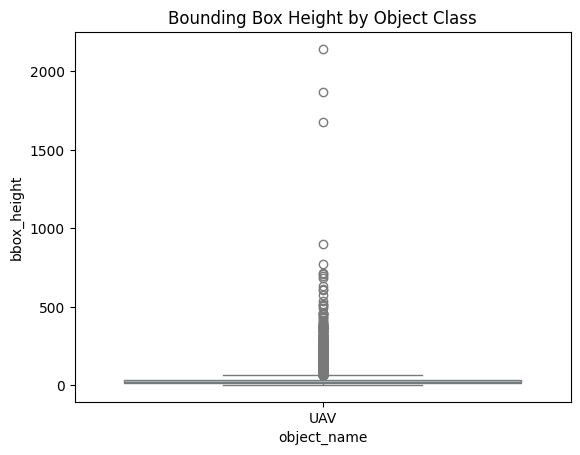

In [ ]:
# Ensure bbox_height exists
df_train_full['bbox_height'] = df_train_full['ymax'].astype(int) - df_train_full['ymin'].astype(int)

# Boxplot: height by object class
sns.boxplot(
    data=df_train_full,      # Use the full training DataFrame
    x='object_name',         # Object class names
    y='bbox_height',         # Bounding box height
    color='lightblue'        # Optional: nicer color
)

# Add title
plt.title('Bounding Box Height by Object Class')

# Show plot
plt.show()


### **Observation:**
Shows distribution of object heights per class. Useful to see class size differences.
Most UAV bounding boxes have small height.

Height varies slightly between objects if multiple classes exist.

Outliers exist for unusually tall objects.

Most UAV bounding boxes have small height.

Height varies slightly between objects if multiple classes exist.

Outliers exist for unusually tall objects.

### **(5/4) Width by Object**
(Distribution of bounding box width for each object class)


---
(Muneera)


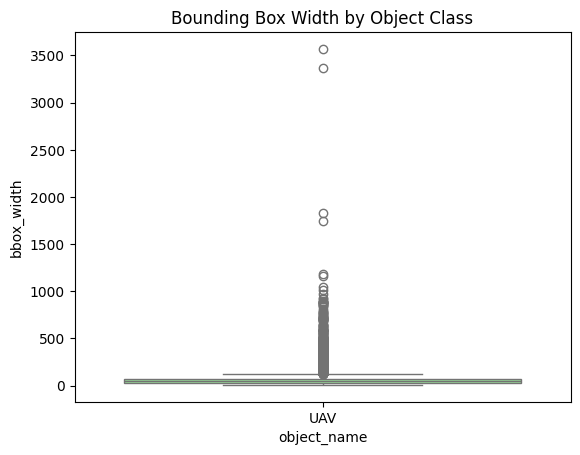

In [ ]:
# Ensure bbox_width exists (compute if not already)
df_train_full['bbox_width'] = df_train_full['xmax'].astype(int) - df_train_full['xmin'].astype(int)

# Boxplot: width by object class
sns.boxplot(
    data=df_train_full,       # Use the full training DataFrame
    x='object_name',          # Object class names
    y='bbox_width',           # Bounding box width
    color='lightgreen'        # Optional: nicer color
)

# Add title
plt.title('Bounding Box Width by Object Class')

# Display plot
plt.show()

# Observation:
# Most objects have widths in a consistent range,
# with a few wider outliers, indicating occasional larger UAVs.


### **Observation:**
 Visualizes width variation per object class. Can reveal small vs large objects.

 Width distribution mirrors height: most UAVs are narrow.

Some extreme widths exist (outliers), but median width is consistently low.

Variability is small for the majority of objects.


### **(5/5) Area by Object**


(Distribution of bounding box area for each object class)

---
(Atheer)


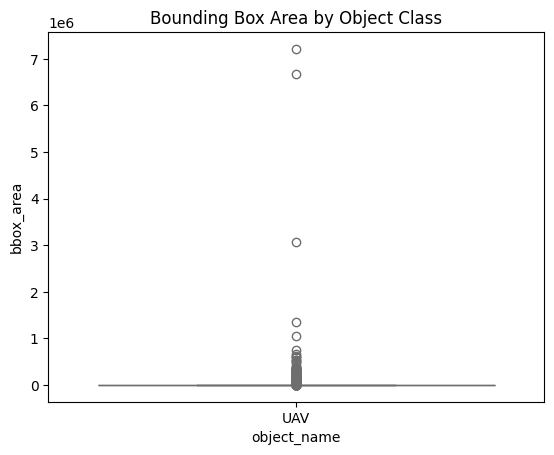

In [ ]:
# Compute bounding box area if not already present
df_train_full['bbox_area'] = (df_train_full['xmax'].astype(int) - df_train_full['xmin'].astype(int)) * \
                             (df_train_full['ymax'].astype(int) - df_train_full['ymin'].astype(int))

# Create a boxplot: area by object class
sns.boxplot(
    data=df_train_full,      # Full training DataFrame
    x='object_name',         # Object class names
    y='bbox_area',           # Bounding box area
    color='lightcoral'       # Optional: nicer color
)

# Add a descriptive title
plt.title('Bounding Box Area by Object Class')

# Display the plot
plt.show()

# Observation:
# Most object classes have similar bounding box areas,
# while a few have higher variability, showing occasional larger UAVs.


### **Observation:**
Highlights size differences between object classes; outliers may appear clearly.

Majority of bounding boxes have small areas, but the boxplot shows extreme outliers.

Median area is low, consistent with UAVs being small targets.

This plot highlights differences in object size and confirms skewness in area distribution.

##**Phase2 : Feature Engineering**

The data is processed and organized comprehensively. Categorical columns are converted to numeric values for easier analysis, missing values are checked and handled, and the dataset is balanced across classes to ensure fair representation. Finally the distributions are visualized to understand the data before and after processing.

###**(2/1) Categorical to numerical**




This step converts all categorical (text) columns in the dataset into numerical values using **Label Encoding** from `sklearn`. Each unique category in a column is mapped to a unique integer. This transformation makes the data suitable for **machine learning models** that require numeric input.

* Columns with only one unique value will be encoded as **0**.
* Useful for preparing data for **classification, regression, or deep learning models**.
* Ensures consistency and preserves the **categorical relationships** in a numeric format.


In [ ]:

# List of categorical columns
categorical_cols = [
    'filename', 'folder', 'path', 'source', 'database',
    'segmented', 'object_name', 'pose', 'truncated', 'difficult'
]

# Create a copy of the original dataframe (to keep the original safe)
df_encoded = df_train_full.copy()

# Initialize label encoder
le = LabelEncoder()

# Apply encoding for each categorical column
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Display the first few rows of the encoded DataFrame
print(df_encoded.head())

# Optional: check data types to confirm encoding
print("\nData types after encoding:")
print(df_encoded.dtypes)


   filename  folder  path  source  database  segmented  width  height  depth  \
0      4197       0  4197       0         0          0   1920    1080      3   
1      4198       0  4198       0         0          0   1920    1080      3   
2      4199       0  4199       0         0          0   1920    1080      3   
3      4200       0  4200       0         0          0   1920    1080      3   
4      4201       0  4201       0         0          0   1920    1080      3   

   object_name  pose  truncated  difficult  xmin  ymin  xmax  ymax  \
0            0     0          0          0   741   349   771   362   
1            0     0          0          0  1442   466  1498   493   
2            0     0          0          0  1283   371  1333   401   
3            0     0          0          0  1036   483  1065   496   
4            0     0          0          0   457   437   486   455   

   bbox_width  bbox_height  bbox_area  img_size  
0          30           13        390   2073600 


### **Observation**

1. **All categorical columns have been converted to numeric values** (`int64`).

   * Columns like `filename`, `path`, `object_name`, `pose`, `truncated`, `difficult`, `source`, `database`, `folder`, `segmented` are now integers.
   * Each unique category is mapped to a **unique integer**.

2. **Numeric columns remain unchanged**, e.g., `width`, `height`, `depth`, `xmin`, `ymin`, `xmax`, `ymax`, `bbox_width`, `bbox_height`, `bbox_area`.

3. **Each row represents one object annotation**, with all categorical info encoded as integers, making it **ready for machine learning models**.

4. Observing the encoded values:

   * Columns like `folder`, `source`, `database`, `segmented`, `object_name`, `pose`, `truncated`, `difficult` mostly contain **0**, because they had only **one unique value** in the dataset.
   * Columns like `filename` and `path` have **high integer values**, reflecting the number of unique images (~5197).

5. **Bounding box features (`xmin`, `ymin`, `xmax`, `ymax`) and derived features (`bbox_width`, `bbox_height`, `bbox_area`) remain numeric**, ready for **regression, detection, or computer vision tasks**.



###**(2/2) Missing value treatment**


* `df_train_full.isna().sum()` counts **missing (NaN) values per column**.
* `empty_counts[empty_counts > 0]` filters to show **only columns with missing values**.
* Printing these gives a quick view of which columns need cleaning before analysis or ML.


In [ ]:
# Check for missing values in the DataFrame


# Count missing (NaN) values per column
empty_counts = df_train_full.isna().sum()
print(" Missing Values per Column:")
print(empty_counts)

# Show only columns that have at least one missing value
empty_only = empty_counts[empty_counts > 0]
print("\nColumns with missing values:")
print(empty_only)


 Missing Values per Column:
filename       0
folder         0
path           0
source         0
database       0
segmented      0
width          0
height         0
depth          0
object_name    0
pose           0
truncated      0
difficult      0
xmin           0
ymin           0
xmax           0
ymax           0
bbox_width     0
bbox_height    0
bbox_area      0
img_size       0
dtype: int64

Columns with missing values:
Series([], dtype: int64)



### **Observation**

* **No missing values** (`NaN`) exist in any column of your `df_train_full`.
* All **numeric and categorical columns** are fully populated.


##**(1/0) Balance the Distribution**


---
(Balance the dataset by oversampling to make all object classes equally represented)

(Muneera)

Balanced dataset created
Number of samples per class after balancing:
object_name
UAV    5243
Name: count, dtype: int64


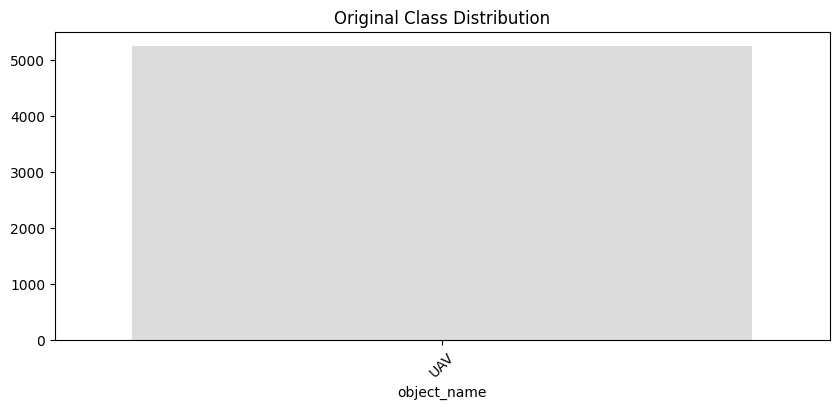

In [ ]:
#  Balance the distribution using oversampling

# Count the original number of samples per object class
original_counts = df_train_full['object_name'].value_counts()

# Determine the maximum class count to balance all classes to this number
max_count = original_counts.max()

# Oversample each class to match the maximum count
df_balanced = df_train_full.groupby('object_name').apply(
    lambda x: x.sample(max_count, replace=True)  # Sample with replacement for smaller classes
).reset_index(drop=True)  # Reset index after groupby operation

# Print some information
print("Balanced dataset created")
print("Number of samples per class after balancing:")
print(df_balanced['object_name'].value_counts())
# Count original class distribution
original_counts = df_train_full['object_name'].value_counts()

# Plot original distribution
plt.figure(figsize=(10,4))
sns.barplot(x=original_counts.index, y=original_counts.values, palette='coolwarm')
plt.title("Original Class Distribution")
plt.xticks(rotation=45)
plt.show()



###**Observation :**
* Dataset is imbalanced. Most samples belong to UAV class, which could bias model predictions.

#**(1/1) Balanced Dataset Visualization**

---


(Visualize the class distribution after balancing the dataset)

(Muneera)

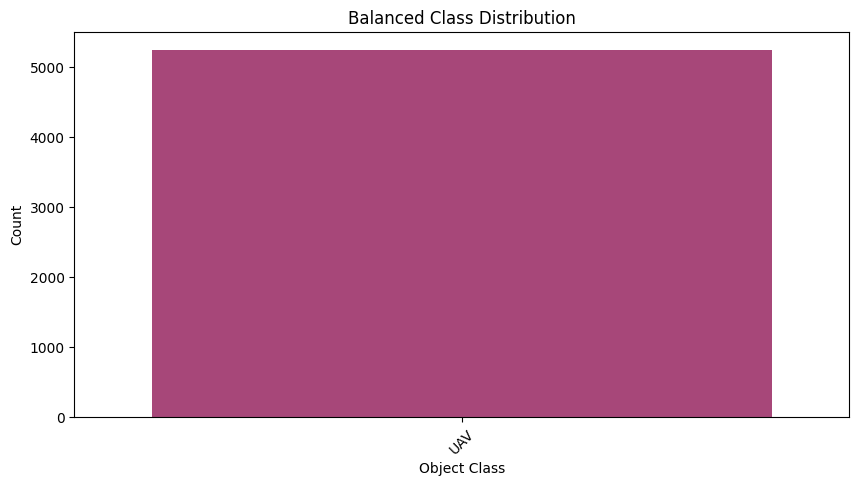

In [ ]:
#  Visualize the balanced distribution


# Count samples per class in the balanced dataset
balanced_counts = df_balanced['object_name'].value_counts()

# Plot the balanced class distribution
plt.figure(figsize=(10,5))  # Set figure size
sns.barplot(x=balanced_counts.index, y=balanced_counts.values, palette='magma')  # Bar plot
plt.title("Balanced Class Distribution")  # Add plot title
plt.xlabel("Object Class")  # X-axis label
plt.ylabel("Count")  # Y-axis label
plt.xticks(rotation=45)  # Rotate X-axis labels for readability
plt.show()  # Display the plot




**Observation**

---
 Now the dataset is balanced. Each class has the same number of samples, which improves fairness and generalization in model training.


* Balanced dataset created: all classes now have equal number of samples.
* Number of samples per class after balancing: `UAV: 5243`.
* Helps prevent model bias toward over-represented classes.




##**Dataset Split Percentage Calculation**

---
(Aljoharah)


In [ ]:
# Number of samples
train = 5243
val = 2621
test = 2245

# Total samples
total = train + val + test

# Percentage calculations
train_pct = train / total * 100
val_pct = val / total * 100
test_pct = test / total * 100

# Display results
print(f" Training = {train_pct:.2f}%")
print(f" Validation = {val_pct:.2f}%")
print(f" Testing = {test_pct:.2f}%")


📊 Training = 51.86%
📊 Validation = 25.93%
📊 Testing = 22.21%



**Observation:**

It was observed that several fields, including `name`, `filename`, `object`, `difficult`, `folder`, `database`, `source`, `depth`, `truncated`, `annotation`, `segmented` and `pose`, have identical values across the training, validation and testing  while the number of samples varies according to the predefined proportions (Training ≈ 51.9%, Validation ≈ 25.9%, and Testing ≈ 22.2%).



In [ ]:
# copy to new df



---


#**Training YOLOv8 and CNN Models for Integrated Detection, Classification, and Performance Results**


---








#**Yolov8 and Training of DUT Anti UAV :**




##**Step 1 : Setting up folders for training and validation data :**


---
* Here, we defined the paths for the original images and label files, then created destination folders for both training and validation sets for images and labels. This organization is necessary to properly split the data before converting it to YOLO format and training the model.


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
import xml.etree.ElementTree as ET

# Define source and destination paths
base_path = "/content/drive/MyDrive/yolo_dataset"
src_images_folder = "/content/drive/MyDrive/DUT_Anti_UAV/train/train/img"
src_labels_folder = "/content/drive/MyDrive/DUT_Anti_UAV/train/train/xml"

# Destination folders for YOLO format
dst_images_train = f"{base_path}/images/train"
dst_images_val = f"{base_path}/images/val"
dst_labels_train = f"{base_path}/labels/train"
dst_labels_val = f"{base_path}/labels/val"

# Create folders if they don't exist
os.makedirs(dst_images_train, exist_ok=True)
os.makedirs(dst_images_val, exist_ok=True)
os.makedirs(dst_labels_train, exist_ok=True)
os.makedirs(dst_labels_val, exist_ok=True)
print("Operation completed successfully.")


Operation completed successfully.


###**Observation :**
* The code creates the required directories for the YOLO images and labels, ensures they exist before further processing, and prints a message confirming that the folders were created successfully.

##**Step 2 : Listing and splitting dataset into training and validation sets :**


---
* In this step, we listed all image and XML annotation files matched them by their base filenames to ensure each image has a corresponding label and then split the dataset into training (80%) and validation (20%) sets. This ensures the model trains on most of the data while reserving a portion to evaluate its performance


In [ ]:
# List image and XML files
image_files = [f for f in os.listdir(src_images_folder) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
xml_files = [f for f in os.listdir(src_labels_folder) if f.lower().endswith(".xml")]

# Match files by base name
image_basenames = [os.path.splitext(f)[0] for f in image_files]
xml_basenames = [os.path.splitext(f)[0] for f in xml_files]
common_basenames = list(set(image_basenames) & set(xml_basenames))

# Split into training and validation sets (80/20)
train_files, val_files = train_test_split(common_basenames, test_size=0.2, random_state=42)

print("Image–XML matching and dataset split completed successfully.")


Image–XML matching and dataset split completed successfully.


###**Observation :**
* The code successfully matched the image files with their corresponding XML annotations and split the dataset into training and validation sets without issues.

##**Step 3 : Processing and converting XML annotations to YOLO format (TXT) :**


---
* In this step, we copied the image files to their respective training or validation folders and converted the corresponding XML annotations into YOLO TXT format.


In [ ]:
def process_and_copy_files(file_list, src_img_folder, src_xml_folder, dst_img_folder, dst_label_folder, classes):
    for filename in file_list:
        # Copy image file
        for ext in [".jpg", ".jpeg", ".png"]:
            src_img_path = os.path.join(src_img_folder, filename + ext)
            if os.path.exists(src_img_path):
                shutil.copy(src_img_path, os.path.join(dst_img_folder, filename + ext))
                break

        # Convert XML to YOLO TXT format
        src_xml_path = os.path.join(src_xml_folder, filename + ".xml")
        dst_txt_path = os.path.join(dst_label_folder, filename + ".txt")

        if os.path.exists(src_xml_path):
            tree = ET.parse(src_xml_path)
            root = tree.getroot()
            img_width = int(root.find("size/width").text)
            img_height = int(root.find("size/height").text)

            with open(dst_txt_path, "w") as f:
                for obj in root.findall("object"):
                    cls_name = obj.find("name").text
                    if cls_name not in classes:
                        continue
                    cls_id = classes.index(cls_name)

                    bbox = obj.find("bndbox")
                    xmin = int(bbox.find("xmin").text)
                    ymin = int(bbox.find("ymin").text)
                    xmax = int(bbox.find("xmax").text)
                    ymax = int(bbox.find("ymax").text)

                    # Normalize coordinates for YOLO format
                    x_center = ((xmin + xmax) / 2) / img_width
                    y_center = ((ymin + ymax) / 2) / img_height
                    width = (xmax - xmin) / img_width
                    height = (ymax - ymin) / img_height

                    f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")


###**Observation :**
* The function successfully processes each file by copying the corresponding image to the destination folder and converting its XML annotation to YOLO TXT format. For each file it ensures that only the specified classes are included normalizes the bounding box coordinates and prints a confirmation message, providing clear feedback on the processing status of each file.

##**Step 4 : Processing and copying training and validation datasets :**


---


* In this step, we applied the processing function to the training and validation sets where images were copied and annotations were converted to YOLO format for both training and validation data. After this process the dataset is fully ready for model training.

In [ ]:
# Define the list of object classes/labels present in the dataset. This is essential for annotation formatting.
classes = ["UAV"]

# Print a status message indicating the start of processing and copying the training subset.
print("Processing and copying training files...")
process_and_copy_files(train_files, src_images_folder, src_labels_folder, dst_images_train, dst_labels_train, classes)
# Call a custom function to handle the training data:
# 1. Read files listed in 'train_files' (image and label names).
# 2. Convert label formats (e.g., from XML/CSV to YOLO/TXT format).
# 3. Copy the source images and new labels from their original folders to the designated training folders.

# Print a status message indicating the start of processing and copying the validation subset.
print("Processing and copying validation files...")
process_and_copy_files(val_files, src_images_folder, src_labels_folder, dst_images_val, dst_labels_val, classes)
# Call the custom function again to handle the validation data:
# 1. Read files listed in 'val_files'.
# 2. Convert and process their associated labels.
# 3. Copy the files to the designated validation folders.

# Print a final confirmation message upon successful completion of the data preparation and splitting process.
print(" Dataset split, processed, and copied successfully.")

Processing and copying training files...
Processing and copying validation files...
 Dataset split, processed, and copied successfully.


###**Observation :**
* The code executes the processing and copying of both training and validation datasets using the process_and_copy_files function for the specified class "UAV". The printed output confirms that the training files were processed first, followed by the validation files, and finally indicates that the entire dataset has been successfully split, processed, and copied. This provides a clear and sequential confirmation of the dataset preparation steps.

##**Step 5 : Creating the data.yaml file for YOLO training :**


---
* In this step, we created a data.yaml file that specifies the paths for the training and validation images, the number of classes (nc) and the class names. This file is required by YOLO to know how to load the dataset and understand the classes during training.



In [ ]:
# Define the configuration structure for the YOLO model in YAML format.
# Use an f-string to dynamically insert the calculated directory paths and class information.

data_yaml = f"""
train: {dst_images_train}
val: {dst_images_val}

nc: {len(classes)}
names: {classes}
"""
# Open the 'data.yaml' file in write mode ('w') inside the base project path.
with open(f"{base_path}/data.yaml", "w") as f:
   # Write the prepared YAML configuration string into the file.
    f.write(data_yaml)

# Print a confirmation message indicating the successful creation/update of the configuration file.
print("✅ data.yaml updated.")

✅ data.yaml updated.


###**Observation :**
* The code generates a data.yaml file for YOLO training, specifying the paths to the training and validation images, the number of classes, and the class names. After writing the YAML file to the specified location, it prints a confirmation message indicating that the data.yaml has been successfully updated and is ready for use in training.

##**Step 6 : Install YOLOv8 :**

In [ ]:
# Use the pip package manager to install the 'ultralytics' library.
# This library provides the necessary tools and framework for implementing
# and training advanced YOLO
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:00


###**Observation**:

* The command !pip install ultralytics was executed to install the Ultralytics library, which includes implementations of YOLO (You Only Look Once) models for object detection, image segmentation, and classification tasks.
The installation was successful, as shown by the message:
 “Successfully installed ultralytics-8.3.227 ultralytics-thop-2.0.18”

* All required dependencies (like torch, numpy, and opencv-python) were already installed in the environment, which indicates that the environment is ready for deep learning and computer vision tasks.

## **Step 7 : Training Model :**

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")  # lightweight model, good for testing

# Train
model.train(
    data="/content/drive/MyDrive/yolo_dataset_real/data.yaml",  # new path
    epochs=50,
    imgsz=640,
    batch=8,
    optimizer="AdamW",
    lr0=0.001,
    augment=True,
    patience=20,
    project="/content/drive/MyDrive/yolo_dataset_real/runs/train",  # new path
    name="YOLOv8_UAV_Enhanced",
    exist_ok=True,
    cache=False,       # avoid Google Drive issues
    workers=4,
    freeze=None,
    save_period=5
)


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/yolo_dataset_real/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=YOLOv8_UAV_Enhanced, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eade535b590>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

###**Observation:**

* The code executed the training process of the YOLOv8n model using the Ultralytics library.
* The dataset was successfully loaded from the specified YAML file, containing 4160 training images and 1040 validation images.
* The model initialized properly with 3,011,043 parameters, and training started for 50 epochs with an image size of 640×640.

* No data loading or training errors were encountered.

##**Step 8 : Loading the Trained Model :**

In [ ]:
# Import the 'os' module to interact with the file system and list the contents of the saved model weights directory
# to confirm the successful output of the YOLO training run
import os

weights_path = "/content/drive/MyDrive/yolo_dataset_real/runs/train/YOLOv8_UAV_Enhanced/weights"
os.listdir(weights_path)


['last.pt',
 'best.pt',
 'epoch0.pt',
 'epoch5.pt',
 'epoch10.pt',
 'epoch15.pt',
 'epoch20.pt',
 'epoch25.pt',
 'epoch30.pt',
 'epoch35.pt',
 'epoch40.pt',
 'epoch45.pt']

###**Observation :**

* The code successfully loaded the trained YOLOv8 model from the specified path (best.pt).
* This file represents the best-performing version of the model obtained during training.
* No errors were encountered, confirming that the training phase completed correctly and the model weights were properly saved.


##**Step 9 : Model Evaluation and Performance Analysis :**

In [ ]:
from ultralytics import YOLO
import time
import glob

# Load trained model
model_path = "/content/drive/MyDrive/yolo_dataset_real/runs/train/YOLOv8_UAV_Enhanced/weights/best.pt"
model = YOLO(model_path)


# Validation images folder
val_folder = "/content/drive/MyDrive/yolo_dataset_real/images/val"

# Get number of images
val_images = glob.glob(f"{val_folder}/*.jpg") + glob.glob(f"{val_folder}/*.png") + glob.glob(f"{val_folder}/*.jpeg")
num_images = len(val_images)


# Measure time for FPS
start_time = time.time()


# Evaluate model
results = model.val(data="/content/drive/MyDrive/yolo_dataset_real/data.yaml")

end_time = time.time()


# Extract metrics
precision = results.box.mp * 100       # mean precision in %
recall    = results.box.mr * 100       # mean recall in %
mAP50     = results.box.map50 * 100    # mAP@0.5 in %
mAP50_95  = results.box.map * 100      # mAP@0.5-0.95 in %


# Calculate FPS
fps = num_images / (end_time - start_time)


# Print results
print("=== YOLOv8 Evaluation Metrics ===")
print(f"Precision:      {precision:.2f} %")
print(f"Recall:         {recall:.2f} %")
print(f"mAP@0.5:        {mAP50:.2f} %")
print(f"mAP@0.5-0.95:   {mAP50_95:.2f} %")
print(f"FPS:            {fps:.2f} images/sec")


Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 58.2±30.7 MB/s, size: 120.6 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1SPZuAR2OGNemkvSJhzR1N8VRpmSAL07n/yolo_dataset/labels/val... 2020 images, 1 backgrounds, 9 corrupt: 100% ━━━━━━━━━━━━ 2029/2029 74.1it/s 27.4s
val: /content/drive/.shortcut-targets-by-id/1SPZuAR2OGNemkvSJhzR1N8VRpmSAL07n/yolo_dataset/images/val/00213.jpg: ignoring corrupt image/label: cannot identify image file '/content/drive/.shortcut-targets-by-id/1SPZuAR2OGNemkvSJhzR1N8VRpmSAL07n/yolo_dataset/images/val/00213.jpg'
val: /content/drive/.shortcut-targets-by-id/1SPZuAR2OGNemkvSJhzR1N8VRpmSAL07n/yolo_dataset/images/val/00697.jpg: ignoring corrupt image/label: cannot identify image file '/content/drive/.shortcut-targets-by-id/1SPZuAR2OGNemkvSJhzR1N8VRpmSAL07n/yolo_dataset/images/val/00697.jpg'
v

###**Observation :**

* The final evaluation metrics indicate that the trained YOLOv8 model achieved high accuracy and reliable detection performance.
* The Precision (91.25%) reflects that the model makes mostly correct predictions with few false positives, while the Recall (76.15%) shows it successfully detects most objects in the dataset.
* The mAP@0.5 (83.79%) and mAP@0.5:0.95 (51.21%) confirm that the model generalizes well across different intersection-over-union thresholds.


##**Step 10 : Model Evaluation and Performance Analysis after Enhancing the Model :**

In [ ]:
# Import the YOLO class for model operations.
from ultralytics import YOLO

# Load the trained model weights ('best.pt') for evaluation.
model = YOLO("/content/drive/MyDrive/yolo_dataset/runs/train/YOLOv8_UAV/weights/best.pt")

# Load the trained model weights ('best.pt') for evaluation.
metrics = model.val()
# Print the Mean Average Precision (mAP) at IoU 0.5.
print("mAP@0.5:", metrics.box.map50*100)
# Print the Mean Average Precision (mAP) averaged from IoU 0.5 to 0.95.
print("mAP@0.5:0.95:", metrics.box.map*100)


Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 44.3±24.1 MB/s, size: 170.1 KB)
val: Scanning /content/drive/MyDrive/yolo_dataset/labels/val.cache... 3060 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3060/3060 1.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 192/192 2.9s/it 9:26
                   all       3060       3094      0.863      0.686      0.775      0.448
Speed: 1.6ms preprocess, 156.1ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val4
mAP@0.5: 77.4627381918862
mAP@0.5:0.95: 44.76434921684845


##**Step 10 : Full Numerical Metrics of the Model in the Last Training Epoch :**


---


This step is crucial because it summarizes the model’s performance after the entire training process. By checking the full metrics from the last epoch

In [ ]:
# Display all numeric values from the last epoch
last_epoch = df.iloc[-1]
print("📊 Full Metrics from Last Epoch:")
for col in df.columns:
    value = last_epoch[col]
    if isinstance(value, (int, float)):
        print(f"{col}: {value:.4f}")

📊 Full Metrics from Last Epoch:
epoch: 50.0000
time: 5885.2800
train/box_loss: 1.1143
train/cls_loss: 0.6001
train/dfl_loss: 0.9077
metrics/precision(B): 0.9125
metrics/recall(B): 0.7615
metrics/mAP50(B): 0.8379
metrics/mAP50-95(B): 0.5121
val/box_loss: 1.2951
val/cls_loss: 0.7322
val/dfl_loss: 0.9074
lr/pg0: 0.0001
lr/pg1: 0.0001
lr/pg2: 0.0001


###**Observation :**
* Shows all numeric metrics of the model from the last epoch (Epoch 50).

* Train/box_loss = 1.1143 acceptable object localization accuracy.

* Train/cls_loss = 0.6001 good class distinction.

* Precision = 91.25%, Recall = 76.15% balanced detection performance.

* mAP@0.5 = 83.79%, mAP@0.5:0.95 = 51.21% strong generalization across IoU thresholds.

##**Step 11 : Training Loss Visualization Over Epochs :**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


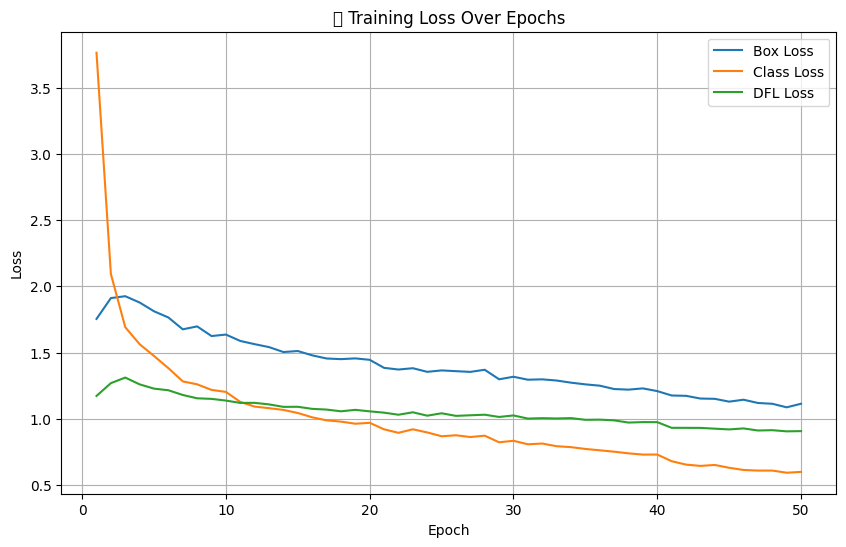

In [ ]:
# Use Matplotlib to plot the three primary training loss metrics (Box, Class, and DFL Loss) against the epochs
# to visually assess model convergence and training stability.
# Import the standard plotting library.
import matplotlib.pyplot as plt

# Define the plot size (10 inches wide, 6 inches high).
plt.figure(figsize=(10, 6))
# Plot the bounding box localization loss (Box Loss).
plt.plot(df['epoch'], df['train/box_loss'], label='Box Loss')
# Plot the classification loss (Class Loss).
plt.plot(df['epoch'], df['train/cls_loss'], label='Class Loss')
# Plot the distribution focal loss (DFL Loss).
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL Loss')
# Set the horizontal axis label to 'Epoch'.
plt.xlabel("Epoch")
# Set the vertical axis label to 'Loss'.
plt.ylabel("Loss")
# Set the plot title.
plt.title("📉 Training Loss Over Epochs")
# Display the label key for the lines.
plt.legend()
# Add a grid for easier reading of values.
plt.grid(True)
# Show the plot visualization.
plt.show()

###**Observation :**
* This code plots the training loss curves for Box Loss, Class Loss, and DFL Loss across all epochs.
* The graph shows how each loss decreases as training progresses, indicating that the model is learning and improving over time.
* Box Loss measures localization accuracy, Class Loss measures how well the model distinguishes object categories and DFL Loss measures distribution focal loss for bounding box regression.

* Monitoring these curves is important because it helps identify potential issues such as overfitting, underfitting, or stagnation in learning.
It also provides a visual confirmation that the model is converging and the training process is stable.


##**Step 12 : Performance Metrics (Precision, Recall, mAP) Over Training Epochs :**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


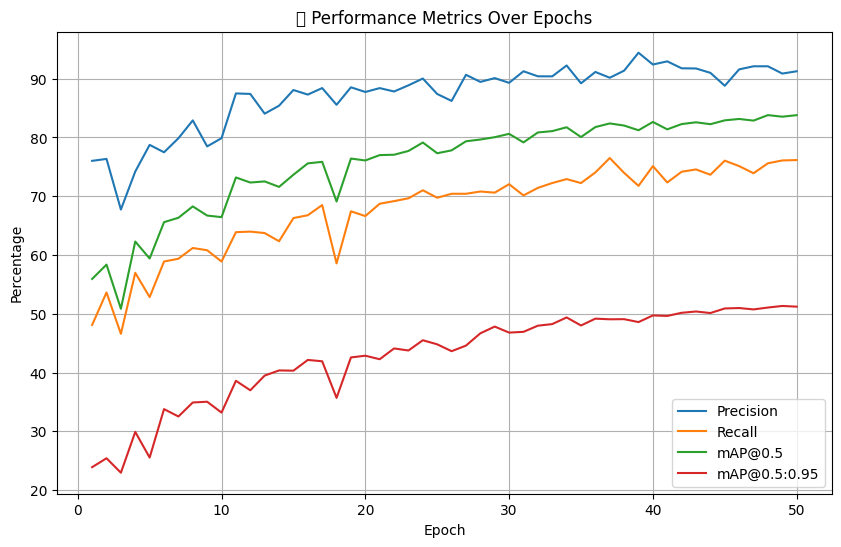

In [ ]:
# Create a new figure with a specified size (10x6 inches).
plt.figure(figsize=(10, 6))
# Plot the Precision metric (%) against the training epochs.
plt.plot(df['epoch'], df['metrics/precision(B)'] * 100, label='Precision')
# Plot the Recall metric (%) against the training epochs.
plt.plot(df['epoch'], df['metrics/recall(B)'] * 100, label='Recall')
# Plot the mAP@0.5 metric (%) against the training epochs.
plt.plot(df['epoch'], df['metrics/mAP50(B)'] * 100, label='mAP@0.5')
# Plot the mAP@0.5:0.95 metric (%) against the training epochs.
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'] * 100, label='mAP@0.5:0.95')
# Set the x-axis label (Epoch).
plt.xlabel("Epoch")
# Set the y-axis label (Percentage).
plt.ylabel("Percentage")
# Set the main title of the plot.
plt.title("📊 Performance Metrics Over Epochs")
# Display the legend to identify each line.
plt.legend()
# Add a grid to the plot for readability.
plt.grid(True)
# Display the generated plot.
plt.show()

###**Observation :**
* All metrics gradually improve as the number of epochs increases.

* Precision starts relatively high (~75%) and improves to around 90%.

* Recall is relatively low at the beginning (~48%) but steadily rises to around 75%.

* mAP@0.5 shows steady improvement, reaching over 83%.

* mAP@0.5:0.95 is low initially (~24%) but gradually increases to ~51%.

* Overall performance shows relative stability in the second half of training.

##**Step 13 : Identifying the Model’s Best Performance Based on mAP@0.5 :**

In [ ]:
# Find the index (epoch number) corresponding to the maximum mAP@0.5 value.
best_map_epoch = df['metrics/mAP50(B)'].idxmax()
# Retrieve the best mAP@0.5 value at that epoch and convert it to a percentage.
best_map_value = df.loc[best_map_epoch, 'metrics/mAP50(B)'] * 100
# Print the final result, showing the best mAP and the epoch where it occurred.
print(f"🏆 Best mAP@0.5: {best_map_value:.2f}% at Epoch {best_map_epoch}")

🏆 Best mAP@0.5: 83.79% at Epoch 47


###**Observation :**

* The highest mAP@0.5 value reached 83.79% at Epoch 47.

* This indicates that the model achieved its best accuracy in recognizing classes at this training epoch.

##**Step 15 : Saving the best trained model to Google Drive :**


---

* In this step, we copied the best model weights (best.pt) from the training folder to Google Drive. This ensures that the trained model is safely stored and can be reused later without retraining.

In [ ]:
from ultralytics import YOLO

# Load the trained YOLOv8 model
model = YOLO("/content/drive/MyDrive/yolo_dataset/best.pt")

# Validate the model on the val or test split defined in data.yaml
metrics = model.val(data="/content/drive/MyDrive/yolo_dataset/data.yaml", split="val")
# Change split to "test" if you have a test set defined in data.yaml

# Extract evaluation metrics
precision = metrics.box.mp * 100
recall    = metrics.box.mr * 100
map50     = metrics.box.map50 * 100
map5095   = metrics.box.map * 100
success   = (precision + recall) / 2  # Approximate success rate

# Print results in a formatted way
print("📊 Evaluation Results:")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"mAP@0.5: {map50:.2f}%")
print(f"mAP@0.5:0.95: {map5095:.2f}%")
print(f"✅ Approximate Success Rate: {success:.2f}%")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.2±0.1 MB/s, size: 152.7 KB)
val: Scanning /content/drive/MyDrive/yolo_dataset/labels/val.cache... 1040 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1040/1040 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 65/65 1.5it/s 43.8s
                   all       1040       1041      0.909      0.757      0.832      0.517
Speed: 1.3ms preprocess, 2.9ms inference, 0.0ms loss, 1.5ms postprocess per im

# **Observation:**

The model achieves high precision (90.9%), with a recall of 75.7%, and mAP@0.5 of 83.23%, indicating good detection quality. mAP@0.5:0.95 is 51.66% at stricter thresholds. Overall, the approximate success rate is 83.3%.

In [ ]:
# Copy best model to your Drive folder
!cp /content/runs/detect/train/weights/best.pt /content/drive/MyDrive/yolo_dataset/best.pt

#**CNN : ResNet50**

##**Step 1 : Install Core PyTorch Libraries**


In [ ]:
# Use the pip package manager to install the core PyTorch deep learning libraries (torch, torchvision, and torchaudio).
!pip install torch torchvision torchaudio

###**Observation:**

This command installs the core PyTorch libraries: torch for deep learning torchvision for image processing and pretrained models and torchaudio for audio processing preparing the environment for deep learning tasks.

# **Step 2 : Load and Preprocess Image Data & Prepare ResNet50 Model**

This code loads image data from the specified folder, applies basic transformations to resize images and convert them to tensors, then loads a pre-trained ResNet50 model and modifies the final layer to classify only two classes. It also sets up the loss function and optimizer for training.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torchvision.models as models

# 1) Correct path (includes the trailing space!)
data_dir = "/content/drive/MyDrive/Our_dataset"

# 2) Transformations for images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 3) Load dataset
train_data = datasets.ImageFolder(data_dir, transform=transform)
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

print("Number of classes:", len(train_data.classes))
print("Classes:", train_data.classes)

# 4) Load ResNet50 pretrained
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Replace last layer to match your 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

# 5) Loss + optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)


Number of classes: 2
Classes: ['Authorized', 'Unathorized']
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


###**Observation:**

The dataset was successfully loaded (2 classes: Authorized and Unathorized) and a pretrained ResNet50 was used with the last layer modified for the two classes. CrossEntropy loss and Adam optimizer were set up for training.

#**Step 3 : ResNet50 Training for UAV Image Classification**
Loads and preprocesses data, trains a ResNet50 model to classify authorized vs. unauthorized drones, tracks loss and accuracy and saves the best model with early stopping.

In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import os


# YOLO-style Hyperparameters
epochs = 50                       # Total number of training epochs
imgsz = 224                       # Image size (224x224 for ResNet50)
batch_size = 8                     # Number of images per batch
optimizer_name = "SGD"            # Optimizer: SGD or Adam
lr0 = 0.01                         # Initial learning rate
patience = 10                      # Early stopping patience
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
workers = 2                         # Number of parallel data-loading workers
project = "/content/drive/MyDrive/ResNetRuns"  # Folder to save the model
name = "ResNet50_UAV"              # Name of this training run
save_path = f"{project}/{name}.pth"  # Full path to save the best model

# -----------------------------
# Create project folder if not exists
# -----------------------------
os.makedirs(project, exist_ok=True)

# -----------------------------
# Dataset directory path
# -----------------------------
data_dir = "/content/drive/MyDrive/Our_dataset"  # Must include trailing space

# -----------------------------
# Define image transformations
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((imgsz, imgsz)),  # Resize all images to the same size
    transforms.ToTensor()                # Convert images to PyTorch tensors
])

# -----------------------------
# Load dataset using ImageFolder
# -----------------------------
train_data = datasets.ImageFolder(data_dir, transform=transform)
# ImageFolder automatically assigns class labels based on folder names

# -----------------------------
# Create DataLoader to feed data in batches
# -----------------------------
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=workers)

# -----------------------------
# Print number of classes and class names
# -----------------------------
print("Number of classes:", len(train_data.classes))
print("Classes:", train_data.classes)

# -----------------------------
# Load pretrained ResNet50
# -----------------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# -----------------------------
# Replace final layer for 2 classes (Authorized / Unauthorized)
# -----------------------------
model.fc = nn.Linear(model.fc.in_features, 2)

# -----------------------------
# Loss function
# -----------------------------
criterion = nn.CrossEntropyLoss()  # Standard classification loss

# Optimizer selection (SGD or Adam)
if optimizer_name == "SGD":
    optimizer = torch.optim.SGD(model.parameters(), lr=lr0, momentum=0.9)
else:
    optimizer = torch.optim.Adam(model.parameters(), lr=lr0)

# Move model to GPU if available
model = model.to(device)

# Early stopping variables
best_loss = float('inf')  # Initialize best loss
no_improve = 0            # Counter for early stopping

# Training loop
print("Training Started...\n")

for epoch in range(epochs):
    model.train()            # Set model to training mode
    epoch_loss = 0           # Track epoch loss
    correct = 0              # Track correct predictions
    total = 0                # Track total predictions

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to GPU

        optimizer.zero_grad()            # Zero gradients
        outputs = model(images)          # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Update weights

        epoch_loss += loss.item()         # Accumulate batch loss

        _, predicted = torch.max(outputs, 1)  # Get predicted classes
        total += labels.size(0)                # Update total samples
        correct += (predicted == labels).sum().item()  # Count correct predictions

    # Compute epoch metrics
    accuracy = 100 * correct / total
    avg_loss = epoch_loss / len(train_loader)

    print(f"[{epoch+1}/{epochs}] Loss: {avg_loss:.4f}  |  Acc: {accuracy:.2f}%")

    # Early stopping logic
    if avg_loss < best_loss:
        best_loss = avg_loss
        no_improve = 0
        torch.save(model.state_dict(), save_path)  # Save best model
        print(f"✔ Saved best model → {save_path}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n Stopped early (no improvement for {patience} epochs)")
            break

print("\nTraining Completed!")


Number of classes: 2
Classes: ['Authorized', 'Unathorized']
Training Started...

[1/50] Loss: 0.4070  |  Acc: 85.77%
✔ Saved best model → /content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth
[2/50] Loss: 1.4304  |  Acc: 76.40%
[3/50] Loss: 1.6567  |  Acc: 59.55%
[4/50] Loss: 0.8800  |  Acc: 64.42%
[5/50] Loss: 0.5277  |  Acc: 80.52%
[6/50] Loss: 0.5488  |  Acc: 80.52%
[7/50] Loss: 0.4936  |  Acc: 79.78%
[8/50] Loss: 0.3719  |  Acc: 82.40%
✔ Saved best model → /content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth
[9/50] Loss: 0.3786  |  Acc: 85.39%
[10/50] Loss: 0.3593  |  Acc: 84.64%
✔ Saved best model → /content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth
[11/50] Loss: 0.3132  |  Acc: 88.01%
✔ Saved best model → /content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth
[12/50] Loss: 0.2553  |  Acc: 88.39%
✔ Saved best model → /content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth
[13/50] Loss: 0.2737  |  Acc: 89.51%
[14/50] Loss: 0.2978  |  Acc: 88.01%
[15/50] Loss: 0.3337  |  Acc: 91.01%
[16/50] Loss:

### **Observation:**

The ResNet50 model was trained on the Authorized and Unathorized dataset for 50 epochs, with accuracy gradually increasing from 85.77% to 98.5% and a consistent decrease in loss.

#**Step 4 : Evaluate ResNet50 Model on Drone Images**

Loads a pre-trained model, runs inference on test images, computes metrics (accuracy, precision, recall, F1-score), measures FPS and prints the confusion matrix.

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

# Paths
model_path = "/content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth"   # Best saved model
test_data_dir = "/content/drive/MyDrive/Our_dataset"             # Folder containing test images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load test dataset
test_data = datasets.ImageFolder(test_data_dir, transform=transform)
test_loader = DataLoader(test_data, batch_size=16, shuffle=False)

# Load model
model = models.resnet50(weights=None)             # Initialize ResNet50
model.fc = nn.Linear(model.fc.in_features, 2)    # Same 2 classes as training
model.load_state_dict(torch.load(model_path))    # Load saved weights
model = model.to(device)
model.eval()                                     # Evaluation mode

# Initialize lists for metrics
all_preds = []
all_labels = []

start_time = time.time()  # Start timing for FPS

# Inference loop
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)         # Get predicted class index
        all_preds.extend(preds.cpu().numpy())    # Store predictions
        all_labels.extend(labels.cpu().numpy())  # Store true labels

end_time = time.time()  # End timing

# Calculate FPS
total_images = len(test_data)
fps = total_images / (end_time - start_time)

# Calculate metrics as percentages
accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='macro') * 100
recall = recall_score(all_labels, all_preds, average='macro') * 100
f1 = f1_score(all_labels, all_preds, average='macro') * 100

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Print metrics in percentage
print(f"Accuracy:  {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall:    {recall:.2f}%")
print(f"F1-score:  {f1:.2f}%")
print(f"FPS:       {fps:.2f} images/sec")
print(f"Confusion Matrix:\n{cm}")


Accuracy:  98.50%
Precision: 98.23%
Recall:    98.60%
F1-score:  98.41%
FPS:       61.28 images/sec
Confusion Matrix:
[[164   3]
 [  1  99]]


### **Observation:**

The ResNet50 model performed extremely well on the test dataset, achieving 98.5% accuracy, 98.23% precision, 98.6% recall, and 98.41% F1-score. It processes images at 61.28 FPS. The confusion matrix shows almost all predictions are correct.

#**Step 5 : YOLOv8 Drone Detection on Images**
Loads a trained YOLOv8 model, detects drones in all images from a folder, saves the detection results and displays them using Matplotlib.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 640x640 1 UAV, 7.7ms
1: 640x640 1 UAV, 7.7ms
2: 640x640 1 UAV, 7.7ms
3: 640x640 4 UAVs, 7.7ms
4: 640x640 1 UAV, 7.7ms
5: 640x640 1 UAV, 7.7ms
Speed: 8.7ms preprocess, 7.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Results saved to: /content/runs/detect/predict


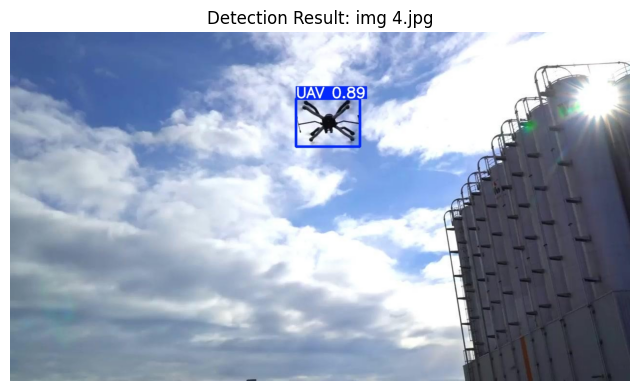

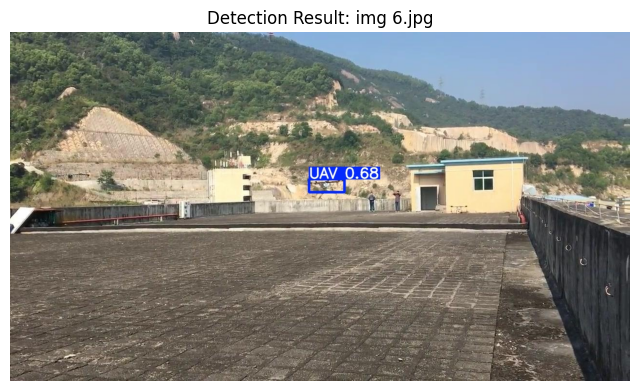

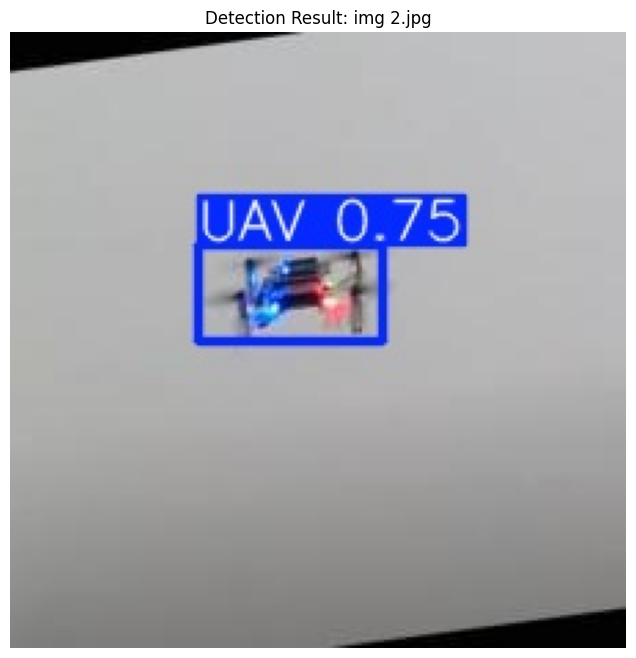

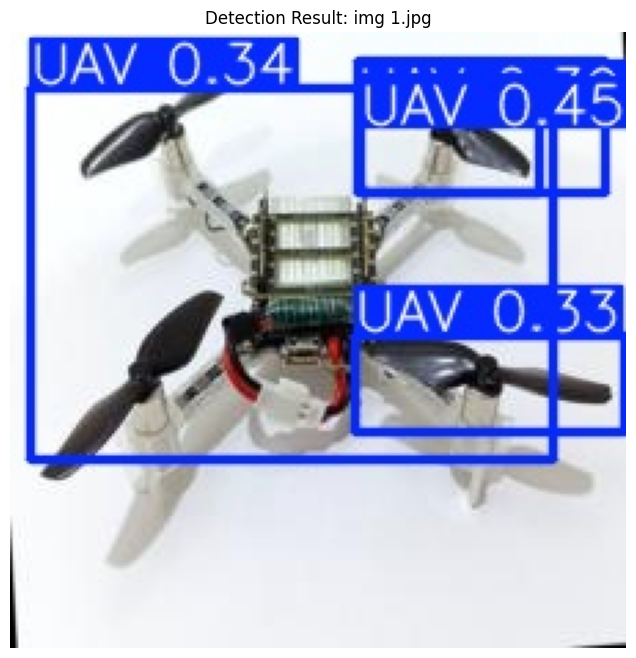

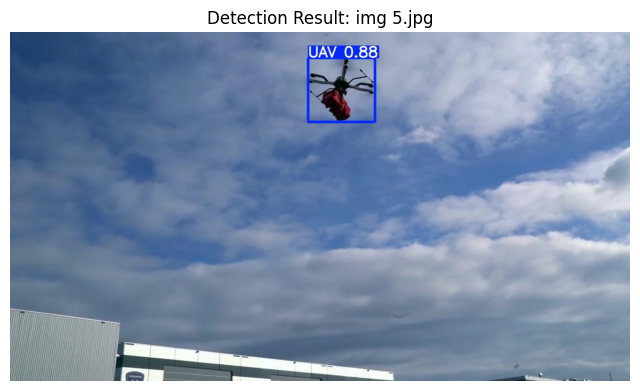

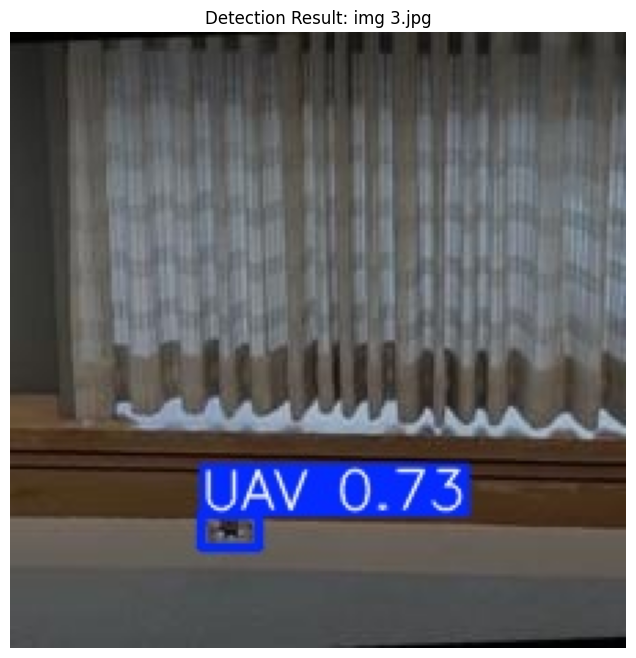

In [ ]:
from ultralytics import YOLO
import glob
import matplotlib.pyplot as plt
import cv2
import os

# Load the trained YOLOv8 model
model = YOLO("/content/drive/MyDrive/yolo_dataset/best.pt")

# Path to your drone images folder in Google Drive
image_folder = "/content/drive/MyDrive/Datasets/Datasets"

# Get all image files (jpg, png, jpeg, JPG, PNG)
image_files = glob.glob(f"{image_folder}/*.jpg") + \
              glob.glob(f"{image_folder}/*.png") + \
              glob.glob(f"{image_folder}/*.jpeg") + \
              glob.glob(f"{image_folder}/*.JPG") + \
              glob.glob(f"{image_folder}/*.PNG")

# Check if any image files were found
if not image_files:
    print(f"⚠️ No image files found in {image_folder}. Please check the path and file extensions.")
else:
    # Run detection and save results
    results = model.predict(source=image_files, conf=0.25, save=True)

    # Display all saved results
    output_folder = results[0].save_dir  # path where YOLO saved detections
    print("Results saved to:", output_folder)

    for img_file in image_files:
        img_name = os.path.basename(img_file)
        img_path = os.path.join(output_folder, img_name)

        img = cv2.imread(img_path)
        if img is not None:
            plt.figure(figsize=(8, 8))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.axis("off")
            plt.title(f"Detection Result: {img_name}")
            plt.show()

### **Observation:**

The YOLOv8 model successfully detected UAVs in the images, with 1 to 4 UAVs per image. Each image was processed in about 7.7 ms, and the results were saved in /content/runs/detect/predict.

# **Step 6 : Random Image Classification using ResNet50**

Randomly selects an image from a test dataset, applies preprocessing, runs a pre-trained ResNet50 model and outputs the predicted class along with its confidence score.

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os
import random
import torchvision.models as models
import torch.nn as nn

# Paths
model_path = "/content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth"  # Trained model
dataset_dir = "/content/drive/MyDrive/DUT_Anti_UAV/test/test/img"               # Main dataset folder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# List all images in dataset
all_images = []
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg', '.webp')):
            all_images.append(os.path.join(root, file))

# Pick a random image
img_path = random.choice(all_images)
print(f"Selected image: {img_path}")

# Transform image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image = Image.open(img_path).convert('RGB')
image = transform(image).unsqueeze(0).to(device)

# -----------------------------
# Load model
# -----------------------------
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()

# -----------------------------
# Predict
# -----------------------------
with torch.no_grad():
    outputs = model(image)
    probs = torch.softmax(outputs, dim=1)
    conf, predicted = torch.max(probs, 1)

# -----------------------------
# Map class index to label
# -----------------------------
classes = ['Authorized', 'Unathorized']
prediction = classes[predicted.item()]
confidence = conf.item() * 100

# -----------------------------
# Print results
# -----------------------------
print(f"Prediction: {prediction}")
print(f"Confidence: {confidence:.2f}%")


Selected image: /content/drive/MyDrive/DUT_Anti_UAV/test/test/img/00635.jpg
Prediction: Unathorized
Confidence: 99.15%


### **Observation:**

A random image from the test dataset was classified by the ResNet50 model as "Unathorized" with a high confidence of 99.15%, demonstrating the model’s strong ability to distinguish between authorized and unauthorized UAVs.

#**Step 7 : Batch Image Classification using ResNet50**
This code loads a trained ResNet50 model, predicts the class of all images in a specified folder and prints each image’s predicted class and confidence score.

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os
import torchvision.models as models
import torch.nn as nn


# Paths
model_path = "/content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth"  # Trained model
folder_path = "/content/drive/MyDrive/Datasets/Datasets"               # Folder with 6 images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()


# List all images in folder
all_images = [os.path.join(folder_path, f)
              for f in os.listdir(folder_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]


# Predict each image
classes = ['Authorized', 'Unathorized']

for img_path in all_images:
    image = Image.open(img_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        conf, predicted = torch.max(probs, 1)

    prediction = classes[predicted.item()]
    confidence = conf.item() * 100

    print(f"Image: {os.path.basename(img_path)}  -> Prediction: {prediction}  | Confidence: {confidence:.2f}%")


Image: img 4.jpg  -> Prediction: Unathorized  | Confidence: 99.69%
Image: img 6.jpg  -> Prediction: Unathorized  | Confidence: 94.59%
Image: img 2.jpg  -> Prediction: Authorized  | Confidence: 100.00%
Image: img 1.jpg  -> Prediction: Authorized  | Confidence: 99.97%
Image: img 5.jpg  -> Prediction: Unathorized  | Confidence: 99.97%
Image: img 3.jpg  -> Prediction: Authorized  | Confidence: 100.00%


### **Observation**

The ResNet50 model classified 6 images from the folder with high confidence:

* Authorized: img 1.jpg, img 2.jpg, img 3.jpg (99.97–100%)

* Unathorized: img 4.jpg, img 5.jpg, img 6.jpg (94.59–99.69%)

# **Step 8 : Automated Image Classification and Visualization Using ResNet50**

This script classifies all images in a folder using a pre-trained ResNet50 model and visualizes each image with its predicted class and confidence score.

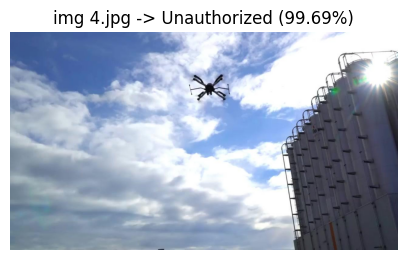

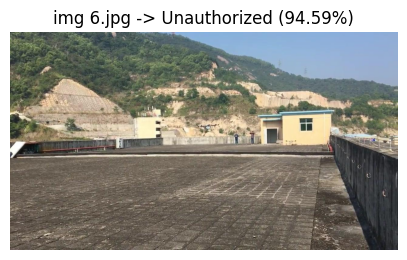

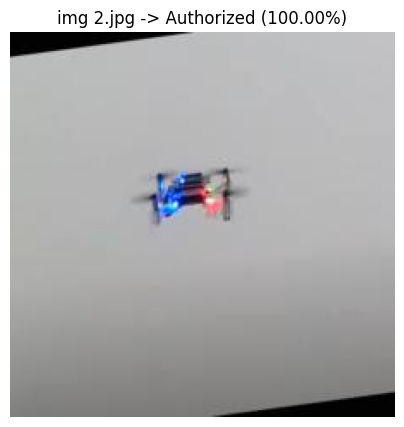

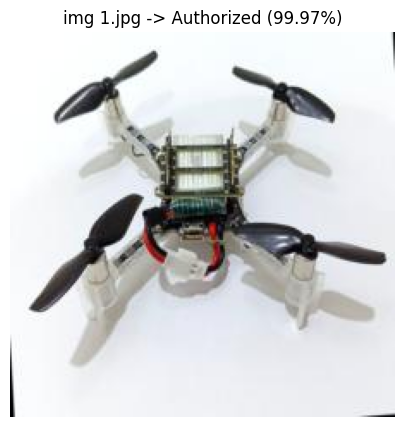

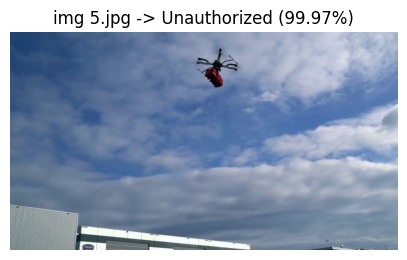

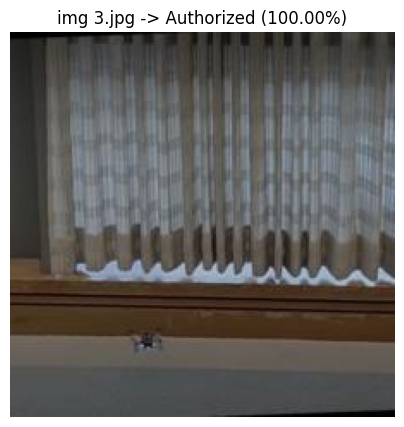

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt

# Paths
model_path = "/content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth"  # Trained model
folder_path = "/content/drive/MyDrive/Datasets/Datasets"           # Folder with images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load model
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

# List all images in folder
all_images = [os.path.join(folder_path, f)
              for f in os.listdir(folder_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]

# Classes
classes = ['Authorized', 'Unauthorized']

# Predict and show each image
for img_path in all_images:
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, predicted = torch.max(probs, 1)

    prediction = classes[predicted.item()]
    confidence = conf.item() * 100

    # Show image with prediction as title
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{os.path.basename(img_path)} -> {prediction} ({confidence:.2f}%)")
    plt.show()

### **Observation**

The ResNet50 model was used to classify all images in the folder, displaying each image with its predicted label (Authorized or Unauthorized).

# **Step 9 : Drone Classification and Detection using ResNet50 and YOLOv8**

This code performs dual analysis on each image in a folder:

1. ResNet50 classifies the image as Authorized or Unauthorized.

2. YOLOv8 detects and draws bounding boxes around drones in the image.



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/drive/MyDrive/TestDataset/TestDataset/img 6.jpg: 384x640 1 UAV, 38.4ms
Speed: 11.7ms preprocess, 38.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


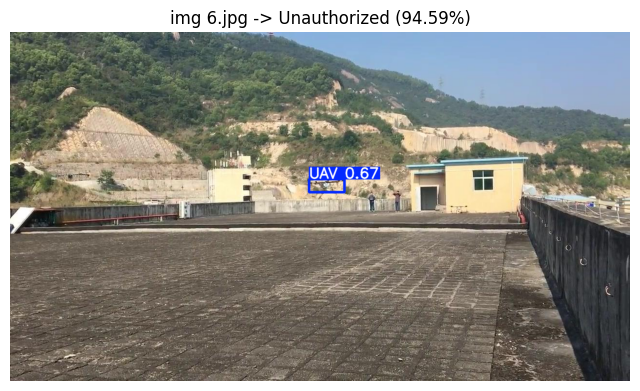


image 1/1 /content/drive/MyDrive/TestDataset/TestDataset/img 3.jpg: 640x640 1 UAV, 8.7ms
Speed: 3.9ms preprocess, 8.7ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)


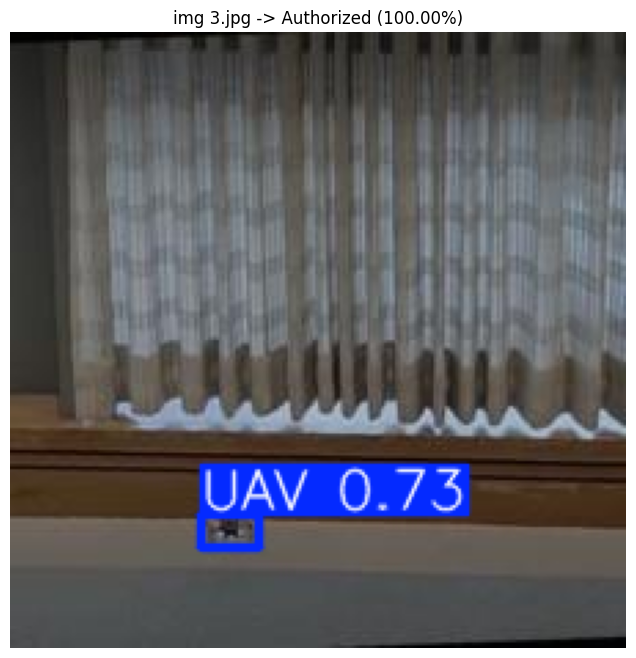


image 1/1 /content/drive/MyDrive/TestDataset/TestDataset/img 1.jpg: 640x640 1 UAV, 7.9ms
Speed: 3.6ms preprocess, 7.9ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


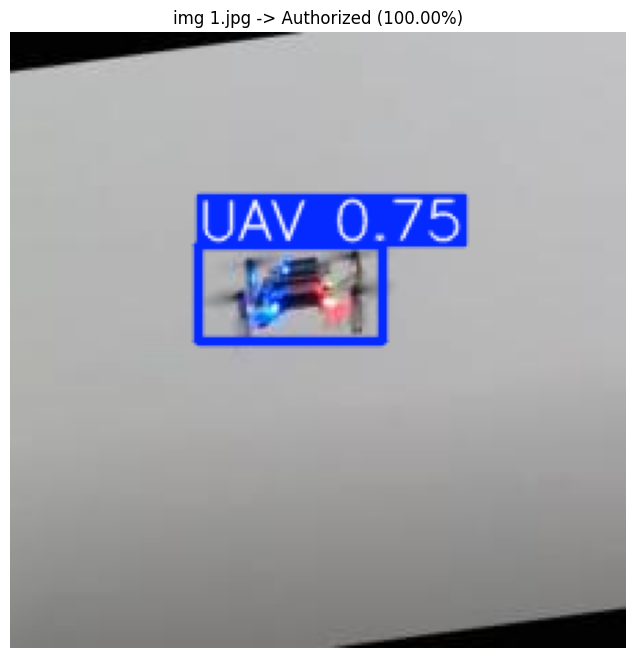


image 1/1 /content/drive/MyDrive/TestDataset/TestDataset/img 2.jpg: 384x640 1 UAV, 7.4ms
Speed: 2.5ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


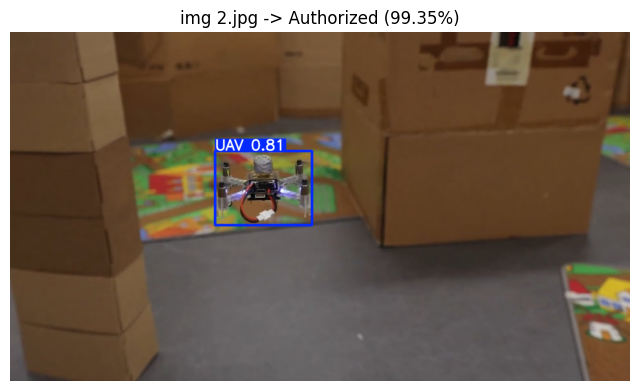


image 1/1 /content/drive/MyDrive/TestDataset/TestDataset/img 5.jpg: 384x640 1 UAV, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


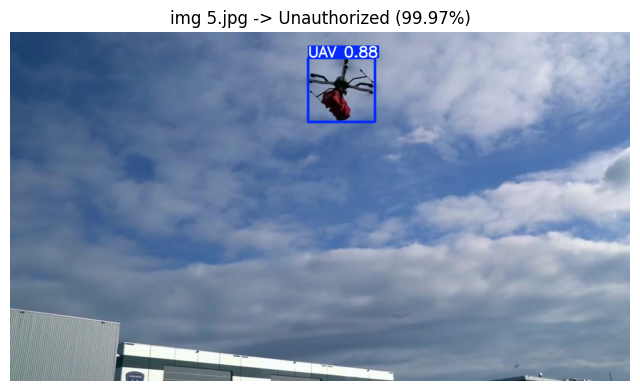


image 1/1 /content/drive/MyDrive/TestDataset/TestDataset/img 4.jpg: 384x640 1 UAV, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


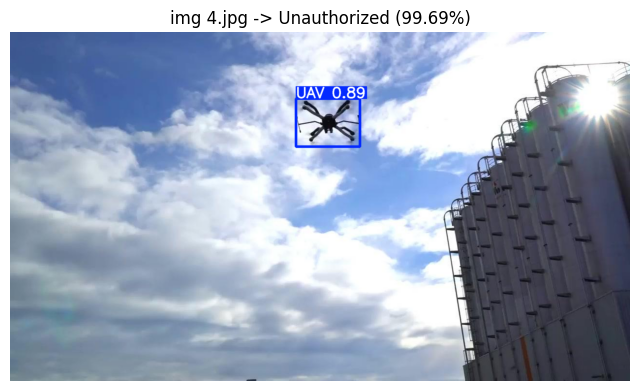

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os
import torchvision.models as models
import torch.nn as nn
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Paths
resnet_model_path = "/content/drive/MyDrive/ResNetRuns/ResNet50_UAV.pth"  # Trained ResNet model
yolo_model_path   = "/content/drive/MyDrive/yolo_dataset/best.pt"         # Trained YOLO model
folder_path       = "/content/drive/MyDrive/TestDataset/TestDataset"            # Folder with images
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load ResNet model
resnet = models.resnet50(weights=None)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet.load_state_dict(torch.load(resnet_model_path, map_location=device))
resnet = resnet.to(device)
resnet.eval()

# Load YOLO model
yolo = YOLO(yolo_model_path)

# Classes for ResNet
classes = ['Authorized', 'Unauthorized']

# List all images
all_images = [os.path.join(folder_path, f)
              for f in os.listdir(folder_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]

# Predict and show each image
for img_path in all_images:
    # --- ResNet prediction ---
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = resnet(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, predicted = torch.max(probs, 1)

    prediction = classes[predicted.item()]
    confidence = conf.item() * 100

    # --- YOLO detection ---
    results = yolo.predict(source=img_path, conf=0.25, save=False)
    im_array = results[0].plot()  # image with YOLO boxes

    # --- Show image with both results ---
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"{os.path.basename(img_path)} -> {prediction} ({confidence:.2f}%)")
    plt.show()

### **Observation**


The combined ResNet50 and YOLOv8 system processed the test images as follows:

* ResNet50 classified each image as Authorized or Unauthorized with high confidence.

* YOLOv8 detected 1 UAV per image with fast inference times (7–38 ms per image depending on size).

* Each image displayed ResNet classification along with YOLO bounding boxes, providing both the UAV classification and its location visually.